In [51]:

import sys
import os
import glob
import re
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numdifftools as nd
import pygsl.rng
from matplotlib import cm
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib import colors as mcolors
from matplotlib.ticker import ScalarFormatter
from scipy.integrate import (
    solve_ivp,
    odeint,
    cumulative_trapezoid,
)
from scipy.interpolate import (
    UnivariateSpline,
    splrep,
    splev,
    CubicSpline,
    interp1d,
    PchipInterpolator,
    InterpolatedUnivariateSpline,
)
import corner

# --- Paths -----------------------------------------------------
# Where the InflationModels package lives, so we can import from it
INFLATION_MODELS_PATH = Path(
    "/Users/epmeador/Desktop/research/rwarthur/"
    "inflation_gravitywaves/inflation_code/InflationModels"
)
if str(INFLATION_MODELS_PATH) not in sys.path:
    sys.path.append(str(INFLATION_MODELS_PATH))

# Where the actual batch/model output directories live
BASE_PATH_ROOT = Path(
    "/Users/epmeador/Desktop/research/rwarthur/"
    "inflation_gravitywaves/inflation_code/"
    "Slow-Roll Parameters Tests/higgs_potential_tests"
)
base_path_root = BASE_PATH_ROOT


# NEED TF

To get LISA good models, we need to load in a TF.

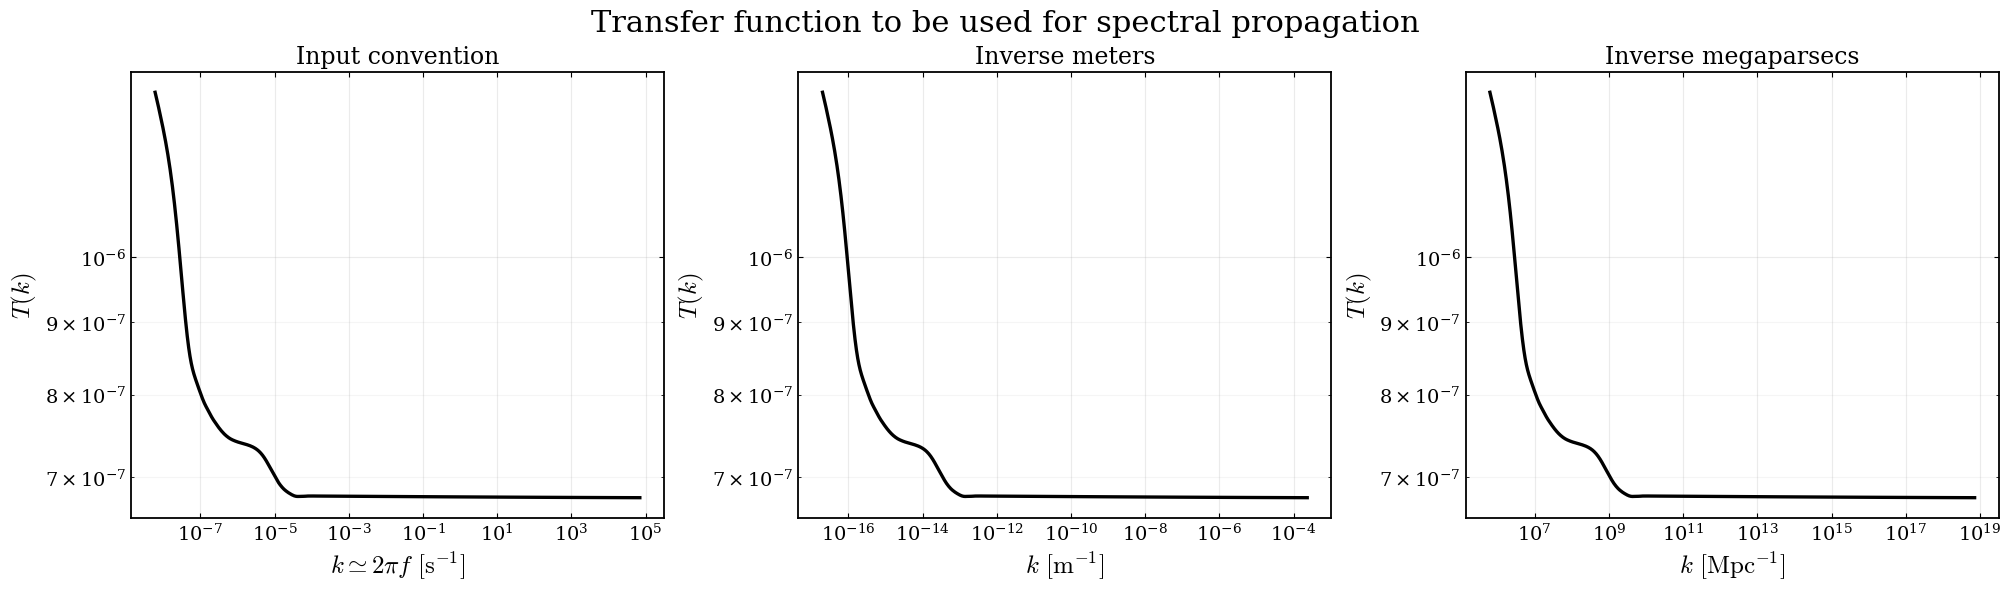

k from data for tf:
6e-09 69740.4

f from data for tf:
9.5493e-10 11099.5

TF median from data:
6.77425e-07 1.3063e-06

k after converting to inverse Mpc:
617562.9710460028 7.178159862110426e+18

ratio of k/(2*pi*f):
0.9999927220232102 1.0000068685629133


In [52]:
plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
    "axes.labelsize": 18,
    "axes.titlesize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.titlesize": 22,
    "axes.linewidth": 1.3,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

base_path_tf = Path(
    "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/"
    "inflation_code/Slow-Roll Parameters Tests"
)

tf_k = np.loadtxt(base_path_tf / "k_file_tf.dat")
tf_f = np.loadtxt(base_path_tf / "f_file_tf.dat")
tf_median = np.loadtxt(base_path_tf / "Tf_median.dat")

tf_k_invm = tf_f * 2.0 * np.pi / 299792458.0
tf_k_invMpc = tf_k_invm * 3.085677581e22

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5.8),
    constrained_layout=True,
)

plot_data = [
    (
        tf_k,
        tf_median,
        r"$k \simeq 2\pi f\ [{\rm s}^{-1}]$",
        r"$T(k)$",
        r"Input convention",
    ),
    (
        tf_k_invm,
        tf_median,
        r"$k\ [{\rm m}^{-1}]$",
        r"$T(k)$",
        r"Inverse meters",
    ),
    (
        tf_k_invMpc,
        tf_median,
        r"$k\ [{\rm Mpc}^{-1}]$",
        r"$T(k)$",
        r"Inverse megaparsecs",
    ),
]

for ax, (x, y, xlabel, ylabel, title) in zip(axes, plot_data):
    ax.loglog(
        x,
        y,
        color="black",
        lw=2.4,
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.grid(True, which="major", alpha=0.25)
    ax.grid(True, which="minor", alpha=0.12)
    ax.minorticks_on()

fig.suptitle(r"Transfer function to be used for spectral propagation", fontsize=22)

plt.savefig(
    "transfer_function_conventions.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("k from data for tf:")
print(tf_k.min(), tf_k.max())

print("\nf from data for tf:")
print(tf_f.min(), tf_f.max())

print("\nTF median from data:")
print(tf_median.min(), tf_median.max())

print("\nk after converting to inverse Mpc:")
print(tf_k_invMpc.min(), tf_k_invMpc.max())

ratio = tf_k / (2.0 * np.pi * tf_f)

print("\nratio of k/(2*pi*f):")
print(np.nanmin(ratio), np.nanmax(ratio))

# START WITH CMB SAFE - Call them in

In [53]:
# ============================================================
# CELL 1: Load all helper functions that validate model by tag and batch directory
#
# This cell loads the helper functions:
#   validate_model_tag, batch_dirs_for, folder_for,
#   get_base_dir, get_param_values_from_dirs
# ============================================================



#Model membership test: If not there will raise value error
def validate_model_tag(model_tag):
    """Checks that the requested model tag is supported. This lives inside model tag dict"""
    if model_tag not in MODEL_TAGS:
        raise ValueError(
            f"Unknown model_tag={model_tag!r}. "
            f"Choose from {list(MODEL_TAGS)}."
        )

#Finds all batch directories given a NEQs, model_tag, and base_path_root
#Searches according to search pattern = base_path_root / f"neqs{NEQS}_{model_tag}_batch*"
def batch_dirs_for(
    NEQS,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """Return all batch directories for a given model and NEQS"""
    validate_model_tag(model_tag)

    base_path_root = Path(base_path_root)

    pattern = (
        base_path_root
        / f"neqs{NEQS}_{model_tag}_batch*"
    )

    return sorted(Path(p) for p in glob.glob(str(pattern)))


def folder_for(
    NEQS,
    param_name,
    value,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """
    Locate the saved model directory corresponding to a parameter value.
    """
    val_str = f"{value:.10e}"

    for batch_dir in batch_dirs_for(
        NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    ):
        pattern = batch_dir / (f"lam2_*_lam3_*_lam4_*_lam5_*")

        for folder in glob.glob(str(pattern)):
            folder = Path(folder)

            if not folder.is_dir():
                continue

            if f"{param_name}_{val_str}" in folder.name:
                return folder

        if folder.exists(): #technicall true for both files and directories
            return folder
        
#         if folder.is_dir(): #could be more specific here
#             return folder

    raise FileNotFoundError(
        f"Missing folder for {param_name}_{val_str} in "
        f"neqs{NEQS}_{model_tag}_batch*" #* means match any sequence of characters
    )

    

#Conveinence wrapper to use with folder_for 
def get_base_dir(
    NEQS,
    param_name,
    base_value,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """Locate the directory containing a chosen base model."""
    return folder_for(
        NEQS,
        param_name,
        base_value,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

def get_param_values_from_dirs(
    NEQS,
    param_name,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
    show_summary=True,
):
    """
    Extract parameter values from all saved model-directory names.

    Returns:
    list of tuple
        Each tuple contains (value, label).
    """
    values = [] #initialize first, to collect parsed (value, label) pairs

    #loop over batches. if no batches will not run and will return empty list
    for batch_dir in batch_dirs_for(
        NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    ):
        #constructs parameter folder pattern
#         pattern = batch_dir / f"{param_name}_*"
        pattern = batch_dir / "lam2_*_lam3_*_lam4_*_lam5_*"

        for folder in glob.glob(str(pattern)): #glob.glob will return a string and gets converted to a Path object
            folder = Path(folder)

            #rejects nondirectories, they have to be
            if not folder.is_dir():
                continue

            try:
                
                folder_name = folder.name

                parameter_order = ["lam2", "lam3", "lam4", "lam5"]
                parts = folder_name.split("_")

                param_index = parameter_order.index(param_name)
                value_index = 2 * param_index + 1

                value_string = parts[value_index]
                value = float(value_string)


                label = rf"${param_name} = {value:.1e}$" #constructs a plotting label 

                values.append((value, label)) #and it stories the result

            except ValueError as exc:
                print(f"Skipping {folder}: {exc}")

    # Remove duplicate parameter values
    unique_values = {}

    for value, label in values:
        unique_values[value] = label

    #sort output according to ascending numerical order
    values = sorted(
        unique_values.items(),
        key=lambda item: item[0],
    )

    if show_summary:
        print("\n" + "=" * 60)
        print(
            f"Summary for model={model_tag}, "
            f"NEQS={NEQS}, parameter={param_name}"
        )
        print("=" * 60)
        print(f"Unique parameter values (or number of viable models) found: {len(values)}") #print total number of models found

        if values:
            print(
                "Parameter range: "
                f"{values[0][0]:.3e} to {values[-1][0]:.3e}"
            )
        else:
            print("Parameter range: none found")

        print("=" * 60 + "\n")

    return values




In [54]:
# ============================================================
# CELL 2: Load all generated models
#
# This cell assumes the helper functions below are ALREADY
# defined in an earlier cell (or imported from a module):
#   validate_model_tag, batch_dirs_for, folder_for,
#   get_base_dir, get_param_values_from_dirs
# ============================================================


# --- Model / scan configuration ---------------------------------
MODEL_TAGS = {
    "higgs": "higgs",
    "nonhiggs": "nonhiggs",
}

# Currently only scanning lam5 (NEQS=8)
SCAN_INFO = {
    6: ("lam3", r"\lambda_3"),
}

colors = {
    5: "pink",
    6: "turquoise",
    7: "plum",
    8: "mediumslateblue",
    9: "blue",
}

# The fiducial ("base") value for each model type, at each NEQS.
# folder_for() / get_base_dir() use this to find the base model's folder.
MODEL_CONFIG = {
    "higgs": {
        "label": "Higgs",
        "lam_base": {
            6: ("lam3", -4.60971e-6),
        },
    },
}

# --- Containers to be filled in the loop below -------------------
base_dirs_by_model = {}      # base/fiducial model folder, per model_tag & NEQS
param_values_by_model = {}   # every scanned lam5 value found, per model_tag & NEQS
batch_dirs_by_model = {}     # list of batch directories, per model_tag & NEQS
batch_counts_by_model = {}   # how many model folders live in each batch

# --- Main loading loop --------------------------------------------
for model_tag, config in MODEL_CONFIG.items():
    print("\n" + "=" * 70)
    print(f"Loading {config['label']} models")
    print("=" * 70)

    # 1) Find the fiducial/base-model directory for each NEQS
    base_dirs_by_model[model_tag] = {}
    for NEQS, (param_name, base_val) in config["lam_base"].items():
        folder = get_base_dir(
            NEQS=NEQS,
            param_name=param_name,
            base_value=base_val,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )
        base_dirs_by_model[model_tag][NEQS] = {
            "param_name": param_name,
            "value": base_val,
            "folder": folder,
        }
        print(
            f"{config['label']} base model: "
            f"NEQS={NEQS}, {param_name}={base_val:.10e}"
        )
        print(f"  {folder}")

    # 2) Find every scanned parameter value across all batches
    param_values_by_model[model_tag] = {}
    for NEQS, (param_name, _) in config["lam_base"].items():
        values = get_param_values_from_dirs(
            NEQS=NEQS,
            param_name=param_name,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )
        param_values_by_model[model_tag][NEQS] = values

    # 3) Find batch directories and count models per batch
    batch_dirs_by_model[model_tag] = {}
    batch_counts_by_model[model_tag] = {}
    for NEQS, (param_name, _) in config["lam_base"].items():
        batch_dirs = batch_dirs_for(
            NEQS=NEQS,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )
        batch_dirs_by_model[model_tag][NEQS] = batch_dirs
        batch_counts_by_model[model_tag][NEQS] = {}

        print(f"\nBatch directories for {config['label']}, NEQS={NEQS}:")
        for batch_dir in batch_dirs:
            print(f"  {batch_dir}")

        print(f"\nModels per batch for {config['label']}, NEQS={NEQS}:")
        for batch_dir in batch_dirs:
            pattern = os.path.join(
                str(batch_dir),
                "lam2_*_lam3_*_lam4_*_lam5_*",
            )
            model_dirs = [
                folder
                for folder in glob.glob(pattern)
                if os.path.isdir(folder)
            ]
            count = len(model_dirs)
            batch_name = os.path.basename(str(batch_dir))
            batch_counts_by_model[model_tag][NEQS][batch_name] = count
            print(f"  {batch_name}: {count}")


Loading Higgs models
Higgs base model: NEQS=6, lam3=-4.6097100000e-06
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch001/lam2_2.7897200000e-04_lam3_-4.6097100000e-06_lam4_0.0000000000e+00_lam5_0.0000000000e+00

Summary for model=higgs, NEQS=6, parameter=lam3
Unique parameter values (or number of viable models) found: 200
Parameter range: -1.041e-04 to 6.079e-06


Batch directories for Higgs, NEQS=6:
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch001
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch002
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch003
  /Users/epmeador/Desktop/research/rwar

In [55]:
# ============================================================
# CELL 3: Reused loading / normalization / comparison helpers
#
# These build on the Cell 2 functions (folder_for, batch_dirs_for,
# etc.) and are used throughout the rest of the notebook:
# plotting raw spectra, normalizing at k_ref, comparing models
# to the base model, and pulling summary-table observables.
# ============================================================


# --- Raw spectra loader -----------------------------------------
def load_specs(
    NEQS,
    param_name,
    value,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """Load scalar and tensor spectra for one saved model."""
    folder = folder_for(
        NEQS,
        param_name,
        value,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

    scalar_file = folder / f"spec_s_neqs{NEQS}.dat"
    tensor_file = folder / f"spec_t_neqs{NEQS}.dat"

    if not scalar_file.exists():
        raise FileNotFoundError(
            f"Scalar spectrum file does not exist: {scalar_file}"
        )

    if not tensor_file.exists():
        raise FileNotFoundError(
            f"Tensor spectrum file does not exist: {tensor_file}"
        )

    scalar_data = np.loadtxt(scalar_file)
    tensor_data = np.loadtxt(tensor_file)

    k_s = scalar_data[:, 0]
    Ps = scalar_data[:, 1]

    k_t = tensor_data[:, 0]
    Pt = tensor_data[:, 1]

    return k_s, Ps, k_t, Pt


# --- Summary CSV loader -------------------------------------------
def load_batch_summaries(
    NEQS,
    base_path_root,
    model_tag="higgs",
):
    """
    Load and combine all summary CSV files for one model family.
    """
    summary_files = []
    for batch_dir in batch_dirs_for(
        NEQS=NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    ):
        summary_file = os.path.join(
            str(batch_dir),
            f"neqs{NEQS}_summary.csv",
        )
        if os.path.exists(summary_file):
            summary_files.append(summary_file)

    if len(summary_files) == 0:
        raise FileNotFoundError(
            f"No summary files found for "
            f"NEQS={NEQS}, model_tag={model_tag}"
        )

    dfs = []
    for summary_file in summary_files:
        df = pd.read_csv(summary_file)
        df["summary_file"] = summary_file
        df["batch_dir"] = os.path.basename(
            os.path.dirname(summary_file)
        )
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)


# --- Array sorting / cleaning --------------------------------------
def prepare_increasing(x, y):
    """
    Return paired arrays with x increasing.

    The input must already be monotonic:
    increasing data are kept, decreasing data are reversed,
    and non-monotonic data raise an error.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.shape != y.shape:
        raise ValueError(
            f"x and y must have the same shape; "
            f"got {x.shape} and {y.shape}"
        )

    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]

    if len(x) == 0:
        raise ValueError("No finite data points remain.")

    if len(x) == 1:
        return x, y

    dx = np.diff(x)

    if np.all(dx >= 0):
        return x, y

    if np.all(dx <= 0):
        return x[::-1], y[::-1]

    raise ValueError(
        "x is non-monotonic; refusing to sort and reorder the trajectory."
    )


# --- Normalization at a reference point -----------------------------
def normalize_curve_at_Nref(
    N,
    Y,
    N_ref=60.0,
    ref_floor=1e-20,
):
    """Normalize a curve Y(N) by its value at N_ref."""
    N_use, Y_use = prepare_increasing(N, Y)

    if not (N_use.min() <= N_ref <= N_use.max()):
        raise ValueError(
            f"N_ref={N_ref} outside range "
            f"[{N_use.min():.6g}, {N_use.max():.6g}]"
        )

    Y_ref = np.interp(N_ref, N_use, Y_use)

    if not np.isfinite(Y_ref):
        raise ValueError(f"Non-finite reference value at N_ref={N_ref}")

    if np.abs(Y_ref) < ref_floor:
        raise ValueError(
            f"Reference value is too small at N_ref={N_ref}: {Y_ref:.3e}"
        )

    return N_use, Y_use / Y_ref, Y_ref


def normalize_at_ref(
    k,
    P,
    k_ref=0.05,
    ref_floor=1e-30,
):
    """Normalize a spectrum P(k) by its value at k_ref."""
    k_use, P_use = prepare_increasing(k, P)

    if not (k_use.min() <= k_ref <= k_use.max()):
        raise ValueError(
            f"k_ref={k_ref} outside range "
            f"[{k_use.min():.3e}, {k_use.max():.3e}]"
        )

    P_ref = np.interp(k_ref, k_use, P_use)

    if not np.isfinite(P_ref):
        raise ValueError(f"Non-finite spectrum value at k_ref={k_ref}")

    if np.abs(P_ref) < ref_floor:
        raise ValueError(
            f"Spectrum reference is too small at k_ref={k_ref}: {P_ref:.3e}"
        )

    if np.any(P_use < 0):
        raise ValueError("Spectrum contains negative values.")

    return k_use, P_use / P_ref, P_ref


def normalize_at_ref_local(x, y, x_ref):
    """
    Sort by increasing x, then divide y by its interpolated value at x_ref.
    Returns (x, y / y(x_ref)) — no ref_floor / negativity checks.
    """
    x, y = prepare_increasing(x, y)

    if not (np.min(x) <= x_ref <= np.max(x)):
        raise ValueError(
            f"k_ref={x_ref} outside range [{np.min(x):.4e}, {np.max(x):.4e}]"
        )

    y_ref = np.interp(x_ref, x, y)

    if np.abs(y_ref) < 1e-30:
        raise ValueError(f"Reference value too small at k_ref={x_ref}")

    return x, y / y_ref


# --- Comparing a model curve to a reference curve --------------------
def fractional_difference_on_overlap(
    x,
    y,
    x_ref,
    y_ref,
    frac_floor=1e-30,
):
    """
    Compute (y - y_ref) / y_ref over the shared x-domain.
    The reference curve is interpolated onto the model's x-grid.
    """
    x_use_all, y_use_all = prepare_increasing(x, y)
    x_ref_use, y_ref_use = prepare_increasing(x_ref, y_ref)

    xmin = max(x_use_all.min(), x_ref_use.min())
    xmax = min(x_use_all.max(), x_ref_use.max())

    if xmin >= xmax:
        return np.array([]), np.array([])

    mask = (x_use_all >= xmin) & (x_use_all <= xmax)

    x_use = x_use_all[mask]
    y_use = y_use_all[mask]

    if len(x_use) == 0:
        return np.array([]), np.array([])

    y_ref_interp = np.interp(x_use, x_ref_use, y_ref_use)

    valid_ref = np.abs(y_ref_interp) > frac_floor

    frac = np.full_like(y_use, np.nan, dtype=float)
    frac[valid_ref] = (
        y_use[valid_ref] - y_ref_interp[valid_ref]
    ) / y_ref_interp[valid_ref]

    return x_use, frac


def fractional_difference_on_reference_grid(
    x_ref,
    y_ref,
    x_cmp,
    y_cmp,
    xmin=None,
    xmax=None,
    frac_floor=1e-30,
):
    """
    Same idea as fractional_difference_on_overlap, but the output is
    reported on the REFERENCE curve's x-grid instead of the model's.
    """
    x_ref, y_ref = prepare_increasing(x_ref, y_ref)
    x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

    xlo = max(x_ref.min(), x_cmp.min())
    xhi = min(x_ref.max(), x_cmp.max())

    if xmin is not None:
        xlo = max(xlo, xmin)
    if xmax is not None:
        xhi = min(xhi, xmax)

    if xlo >= xhi:
        return np.array([]), np.array([])

    mask = (x_ref >= xlo) & (x_ref <= xhi)

    x_use = x_ref[mask]
    y_ref_use = y_ref[mask]

    if len(x_use) == 0:
        return np.array([]), np.array([])

    y_cmp_interp = np.interp(x_use, x_cmp, y_cmp)

    valid = np.abs(y_ref_use) > frac_floor

    frac = np.full_like(y_ref_use, np.nan, dtype=float)
    frac[valid] = (
        y_cmp_interp[valid] - y_ref_use[valid]
    ) / y_ref_use[valid]

    return x_use, frac


# --- Summary-table observable lookups -------------------------------
# NOTE: these three rely on notebook-level globals (summary_all, NEQS,
# scan_name, model_tag, base_path_root) rather than taking them as
# arguments. Make sure those variables are set before calling these.
def get_summary_row(value):
    matches = summary_all.loc[
        np.isclose(
            summary_all[scan_name].to_numpy(dtype=float),
            value,
            rtol=1e-8,
            atol=max(1e-15, abs(value) * 1e-8),
        )
    ]

    if matches.empty:
        raise FileNotFoundError(
            f"No summary row found for "
            f"{scan_name}={value:.10e}, "
            f"model={model_tag}"
        )

    return matches.iloc[0]


def load_observables(value):
    row = get_summary_row(value)

    return (
        float(row["r"]),
        float(row["n_s"]),
        float(row["alpha_s"]),
    )


def load_path(value):
    val_str = f"{value:.10e}"

    folder = folder_for(
        NEQS=NEQS,
        param_name=scan_name,
        value=value,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

    path_matches = list(
        folder.glob(
            f"path_neqs{NEQS}_lam2_*_lam3_*_lam4_*_lam5_*.dat"
        )
    )

    if not path_matches:
        raise FileNotFoundError(f"Missing path file inside: {folder}")

    file_path = path_matches[0]

    return pd.read_csv(
        file_path,
        sep=r"\s+",
        header=None,
    ).values


# --- Misc -------------------------------------------------------------
def sanitize_lam_values(vals):
    """Convert a list of (value, label) tuples or plain values to a float array."""
    return np.array(
        [x[0] if isinstance(x, tuple) else x for x in vals],
        dtype=float,
    )

# CMB DATA

In [56]:
# Explicit plotting ranges
K_PIVOT = 0.05

# CMB-scale scalar window
K_SCALAR_MIN = 1e-4
K_SCALAR_MAX = 1e-1

# Leave tensor range unrestricted in raw-spectrum plots
K_TENSOR_MIN = None
K_TENSOR_MAX = None

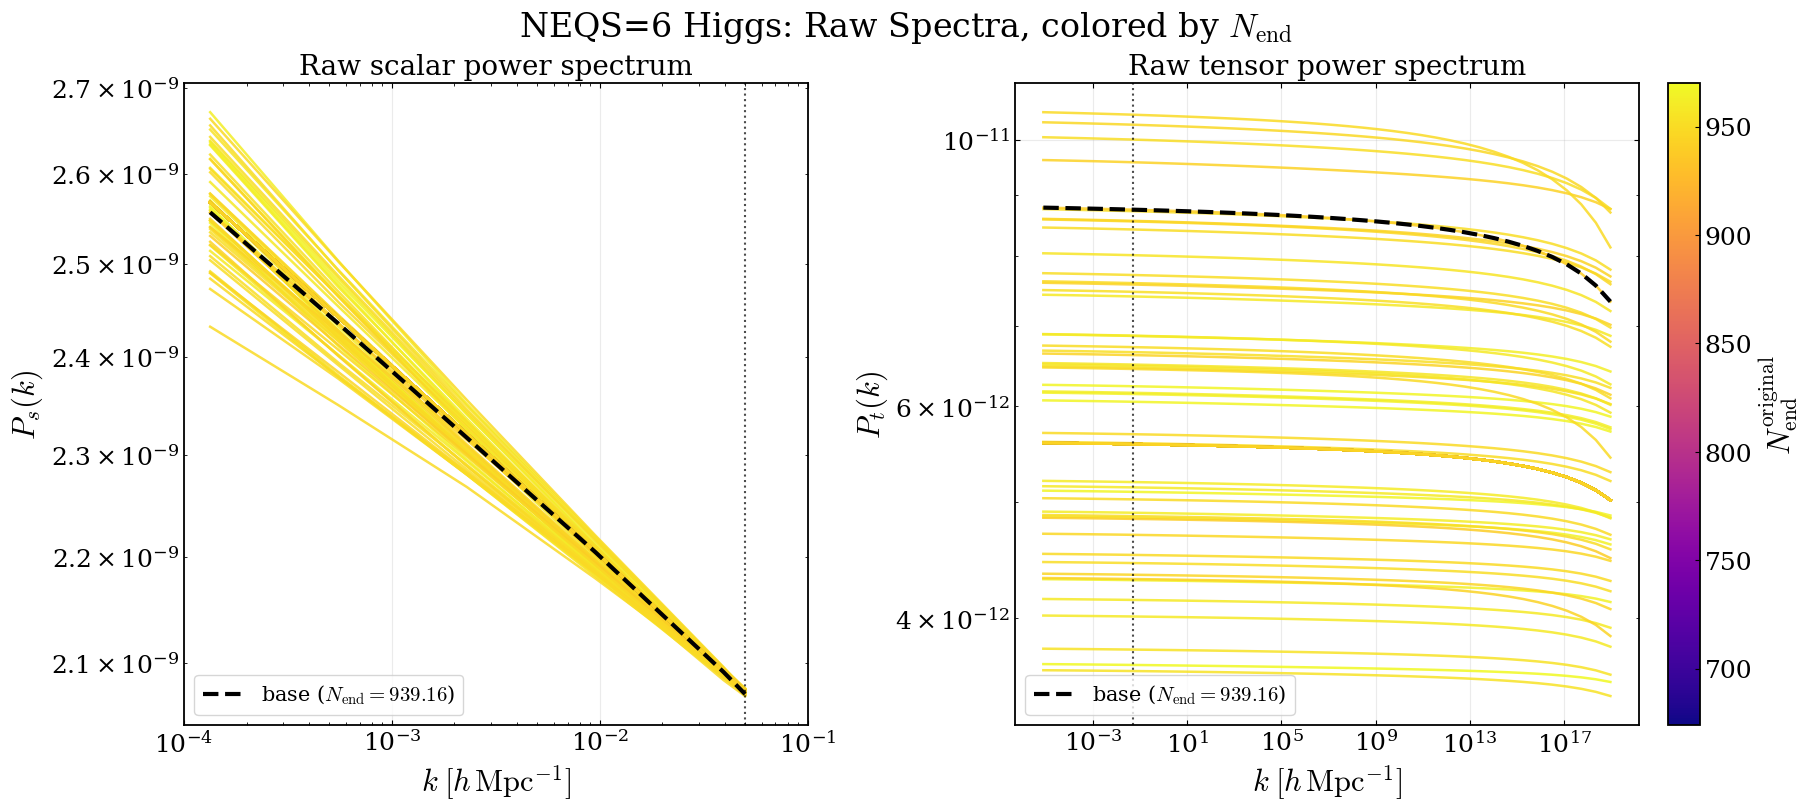

In [57]:
# ============================================================
# CELL 4 (revised): Plot raw, unshifted power spectra
#
# Same raw Ps(k)/Pt(k) curves as before, but now:
#   - uses the same "paper-ready" matplotlib style as
#     plot_filtered_spectra_by_ns_colored_by_Nend
#   - colors each curve by original_N_end (pulled from the
#     summary CSVs), not by lam5 -- since your batches vary
#     more than just lam5, N_end is the more meaningful axis
# ============================================================

# --- Paper-ready plot style ----------------------------------------
# NOTE: this affects every plot made for the rest of the kernel
# session, not just this cell. Consider moving this block to its
# own "set style" cell near the top of the notebook and running it
# once, instead of repeating it in every plotting function.
plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
    "axes.labelsize": 22,
    "axes.titlesize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15,
    "figure.titlesize": 24,
    "axes.linewidth": 1.3,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

NEQS = 6
model_tag = "higgs"
scan_name, scan_symbol = SCAN_INFO[NEQS]
k_ref = 0.05  # your pivot scale, hMpc^-1

lam_values = sanitize_lam_values(param_values_by_model[model_tag][NEQS])
base_val = MODEL_CONFIG[model_tag]["lam_base"][NEQS][1]

# --- Pull N_end for each model from the summary CSVs -----------------
summary_all = load_batch_summaries(NEQS, base_path_root, model_tag=model_tag)


def get_Nend(value):
    """Look up original_N_end for one lam5 value from the summary table."""
    row_match = summary_all.loc[np.isclose(summary_all[scan_name], value)]
    if len(row_match) == 0:
        return None
    return float(row_match.iloc[0]["original_N_end"])


# Collect (lam_val, N_end, k_s, Ps, k_t, Pt) for every model we can load
loaded_models = []
for lam_val in lam_values:
    Nend = get_Nend(lam_val)
    if Nend is None:
        print(f"No summary row for {scan_name}={lam_val:.5e}, skipping")
        continue

    try:
        k_s, Ps, k_t, Pt = load_specs(
            NEQS,
            scan_name,
            lam_val,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )
    except FileNotFoundError as e:
        print(f"Skipping {scan_name}={lam_val:.5e}: {e}")
        continue

    loaded_models.append((lam_val, Nend, k_s, Ps, k_t, Pt))

Nends = np.array([m[1] for m in loaded_models])

# --- Color scale based on N_end, not lam5 -----------------------------
cmap = plt.get_cmap("plasma")
norm = mcolors.Normalize(vmin=np.nanmin(Nends), vmax=np.nanmax(Nends))

fig, (ax_s, ax_t) = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

for lam_val, Nend, k_s, Ps, k_t, Pt in loaded_models:
    color = cmap(norm(Nend))
#     ax_s.loglog(k_s, Ps, color=color, lw=1.8, alpha=0.85)
#     ax_t.loglog(k_t, Pt, color=color, lw=1.8, alpha=0.85)

    scalar_mask = (
        (k_s >= K_SCALAR_MIN)
        & (k_s <= K_SCALAR_MAX)
    )

    ax_s.loglog(
        k_s[scalar_mask],
        Ps[scalar_mask],
        color=color,
        lw=1.8,
        alpha=0.85,
    )

    ax_t.loglog(
        k_t,
        Pt,
        color=color,
        lw=1.8,
        alpha=0.85,
    )

# overplot the base model in black for reference
Nend_base = get_Nend(base_val)
k_s_base, Ps_base, k_t_base, Pt_base = load_specs(
    NEQS,
    scan_name,
    base_val,
    base_path_root=base_path_root,
    model_tag=model_tag,
)
base_label = (
    rf"base ($N_{{\rm end}}={Nend_base:.2f}$)"
    if Nend_base is not None
    else "base model"
)
# ax_s.loglog(k_s_base, Ps_base, color="black", lw=3, ls="--", label=base_label)

base_scalar_mask = (
    (k_s_base >= K_SCALAR_MIN)
    & (k_s_base <= K_SCALAR_MAX)
)

ax_s.loglog(
    k_s_base[base_scalar_mask],
    Ps_base[base_scalar_mask],
    color="black",
    lw=3,
    ls="--",
    label=base_label,
)
ax_t.loglog(k_t_base, Pt_base, color="black", lw=3, ls="--", label=base_label)

for ax, title, ylabel in [
    (ax_s, "Raw scalar power spectrum", r"$P_s(k)$"),
    (ax_t, "Raw tensor power spectrum", r"$P_t(k)$"),
]:
    ax.axvline(k_ref, color="black", ls=":", alpha=0.7)
    ax.set_xlabel(r"$k$")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend()
    
    
ax_s.set_xlim(K_SCALAR_MIN, K_SCALAR_MAX)
ax_s.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
ax_t.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax_s, ax_t], pad=0.02)
cbar.set_label(r"$N_{\rm end}^{\rm original}$")
cbar.ax.tick_params(direction="in")

fig.suptitle(f"NEQS={NEQS} {MODEL_CONFIG[model_tag]['label']}: Raw Spectra, colored by $N_{{\\rm end}}$")

fig.savefig(
    f"paper_{model_tag}_neqs{NEQS}_{scan_name}_raw_spectra_colored_by_Nend.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Total accepted models loaded: 200
Models passing CMB cut: 200
Models FAILING CMB cut: 0
All accepted models pass the pivot-scale cut. YOU GO GIRL

r_flow vs r_spec cross-check (nearest-k, no interpolation):
  mean |delta_r| = 9.244e-05
  max  |delta_r| = 1.716e-04


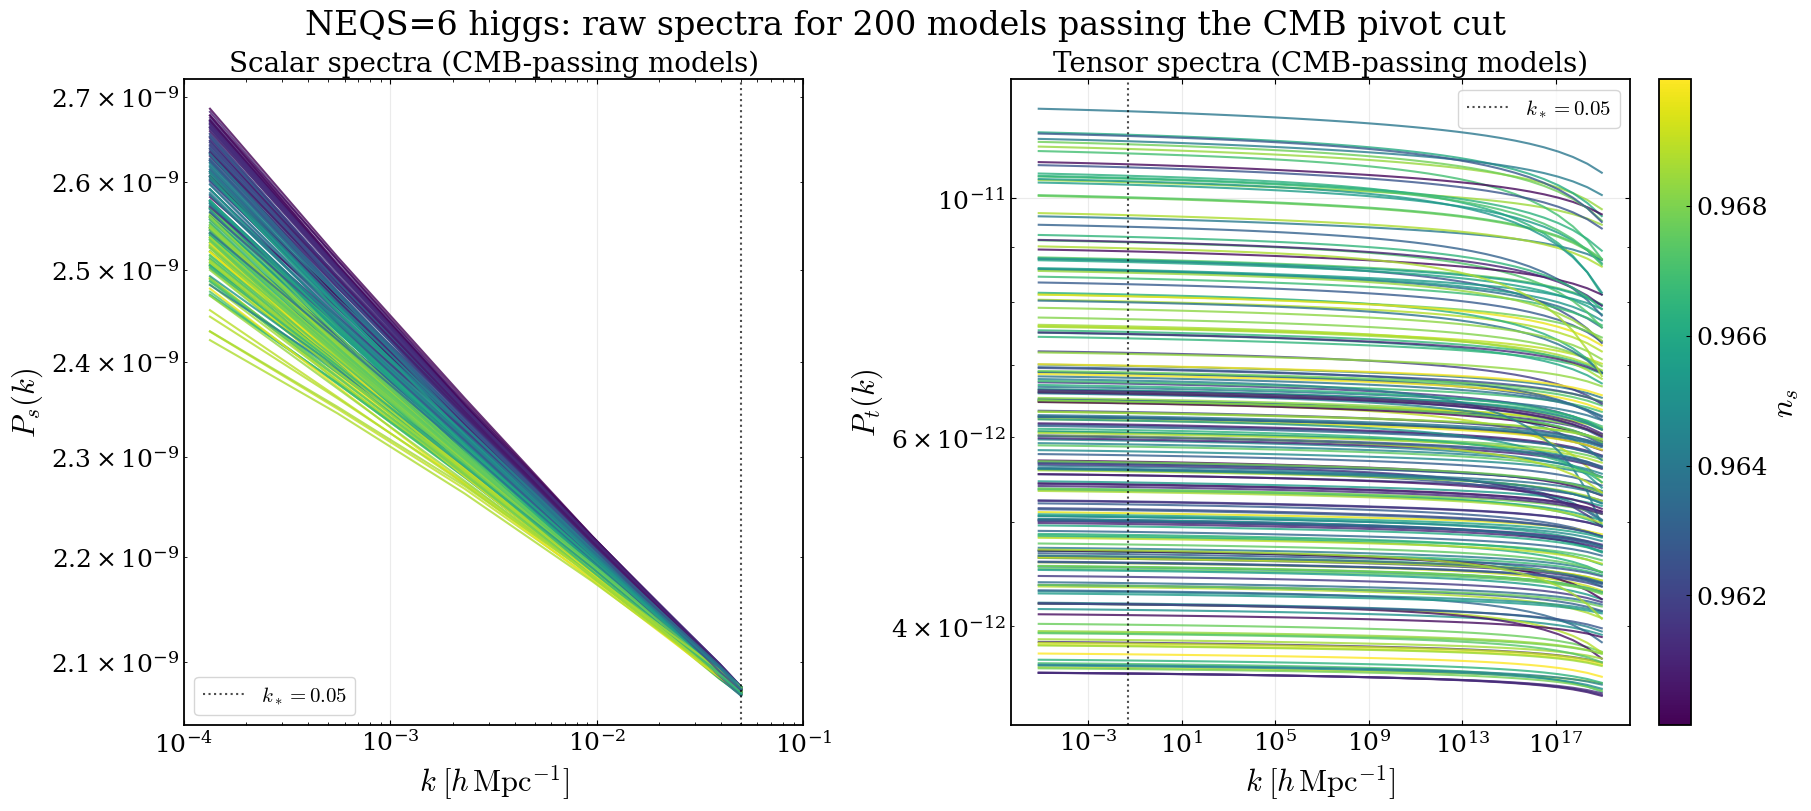

In [58]:
# ============================================================
# CELL 5: Confirm r (and the CMB cut) at the pivot scale
#
# NOTE: looking at the driver script, `r`, `n_s`, `alpha_s` saved
# in the summary CSV are evaluated at N_CMB = 55, not N = 60
# (the driver evolves the state from N=60 down to N=55 with
# get_state_at_N before computing tsratio/specindex/dspecindex).
# So r_flow already corresponds to ~ the same place as k_pivot=0.05.
# The small delta_r you saw earlier is spectrum discretization
# (only 41 saved k-points, nearest-neighbor lookup), not an
# N=60-vs-N=55 mismatch.
# ============================================================

NEQS = 6
model_tag = "higgs"
k_pivot = 0.05

# --- Reproduce the driver's CMB acceptance window -------------------
PIVOT_NMIN, PIVOT_NMAX = 0.96, 0.97

R_TARGET = 0.003664125
R_DELTA = 0.002
PIVOT_RMIN = R_TARGET - R_DELTA
PIVOT_RMAX = R_TARGET + R_DELTA


ALPHA_TARGET = -0.000630587
ALPHA_DELTA = 0.002


PIVOT_ALPHA_MIN = ALPHA_TARGET - ALPHA_DELTA
PIVOT_ALPHA_MAX = ALPHA_TARGET + ALPHA_DELTA

# --- Load every accepted model across all batches --------------------
summary_all = load_batch_summaries(NEQS, base_path_root, model_tag=model_tag)
print(f"Total accepted models loaded: {len(summary_all)}")

# --- Re-apply the same cut the driver already enforced -----------------
# This is the "super duper check" -- everything SHOULD pass, since the
# accept/reject decision already happened at generation time.
pass_ns = (PIVOT_NMIN < summary_all["n_s"]) & (summary_all["n_s"] < PIVOT_NMAX)
pass_r = (PIVOT_RMIN < summary_all["r"]) & (summary_all["r"] < PIVOT_RMAX)
pass_alpha = (
    (PIVOT_ALPHA_MIN < summary_all["alpha_s"])
    & (summary_all["alpha_s"] < PIVOT_ALPHA_MAX)
)

summary_all["passes_cmb_cut"] = pass_ns & pass_r & pass_alpha

n_pass = int(summary_all["passes_cmb_cut"].sum())
n_fail = int((~summary_all["passes_cmb_cut"]).sum())

print(f"Models passing CMB cut: {n_pass}")
print(f"Models FAILING CMB cut: {n_fail}")

if n_fail > 0:
    print("\nModels that failed the check (should be empty!):")
    fail_cols = ["outdir", "n_s", "r", "alpha_s"]
    print(
        summary_all.loc[~summary_all["passes_cmb_cut"], fail_cols]
        .to_string(index=False)
    )
else:
    print("All accepted models pass the pivot-scale cut. YOU GO GIRL")


# --- Cross-check r_flow against r computed directly from the spectra ---
def r_spec_at_pivot(outdir, k_pivot=k_pivot):
    """Nearest-k lookup of Pt/Ps at k_pivot, straight from the saved spectra."""
    s = np.loadtxt(os.path.join(outdir, f"spec_s_neqs{NEQS}.dat"))
    t = np.loadtxt(os.path.join(outdir, f"spec_t_neqs{NEQS}.dat"))
    k_s, Ps = s[:, 0], s[:, 1]
    k_t, Pt = t[:, 0], t[:, 1]
    i_s = np.argmin(np.abs(k_s - k_pivot))
    i_t = np.argmin(np.abs(k_t - k_pivot))
    return Pt[i_t] / Ps[i_s]


r_spec_vals = []
for _, row in summary_all.iterrows():
    try:
        r_spec_vals.append(r_spec_at_pivot(row["outdir"]))
    except (OSError, FileNotFoundError) as e:
        print(f"Could not load spectra for {row['outdir']}: {e}")
        r_spec_vals.append(np.nan)

summary_all["r_spec"] = r_spec_vals
summary_all["delta_r"] = summary_all["r_spec"] - summary_all["r"]

print("\nr_flow vs r_spec cross-check (nearest-k, no interpolation):")
print(f"  mean |delta_r| = {summary_all['delta_r'].abs().mean():.3e}")
print(f"  max  |delta_r| = {summary_all['delta_r'].abs().max():.3e}")


# --- Plot raw spectra for all CMB-passing models, colored by n_s --------
# (Run the paper-style rcParams block from Cell 4 first if you haven't
# already this session -- it persists for the rest of the kernel.)
passing = summary_all[summary_all["passes_cmb_cut"]].copy()

cmap = plt.get_cmap("viridis")
norm = mcolors.Normalize(vmin=passing["n_s"].min(), vmax=passing["n_s"].max())

# K_SCALAR_MIN = 1e-4
# K_SCALAR_MAX = 1e-1


fig, (ax_s, ax_t) = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

for _, row in passing.iterrows():
    try:
        s = np.loadtxt(os.path.join(row["outdir"], f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(row["outdir"], f"spec_t_neqs{NEQS}.dat"))
    except (OSError, FileNotFoundError):
        continue

    color = cmap(norm(row["n_s"]))
#     ax_s.loglog(s[:, 0], s[:, 1], color=color, lw=1.5, alpha=0.8)
#     ax_t.loglog(t[:, 0], t[:, 1], color=color, lw=1.5, alpha=0.8)


    scalar_mask = (
        (s[:, 0] >= K_SCALAR_MIN)
        & (s[:, 0] <= K_SCALAR_MAX)
    )

    ax_s.loglog(
        s[scalar_mask, 0],
        s[scalar_mask, 1],
        color=color,
        lw=1.5,
        alpha=0.8,
    )

    ax_t.loglog(
        t[:, 0],
        t[:, 1],
        color=color,
        lw=1.5,
        alpha=0.8,
    )

for ax, title, ylabel in [
    (ax_s, "Scalar spectra (CMB-passing models)", r"$P_s(k)$"),
    (ax_t, "Tensor spectra (CMB-passing models)", r"$P_t(k)$"),
]:
    ax.axvline(k_pivot, color="black", ls=":", alpha=0.7, label=rf"$k_*={k_pivot}$")
    ax.set_xlabel(r"$k$")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend()
    
ax_s.set_xlim(K_SCALAR_MIN, K_SCALAR_MAX)
ax_s.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
ax_t.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax_s, ax_t], pad=0.02)
cbar.set_label(r"$n_s$")

fig.suptitle(
    f"NEQS={NEQS} {model_tag}: raw spectra for "
    f"{len(passing)} models passing the CMB pivot cut"
)
plt.show()

Processed 200 / 200 CMB-passing models


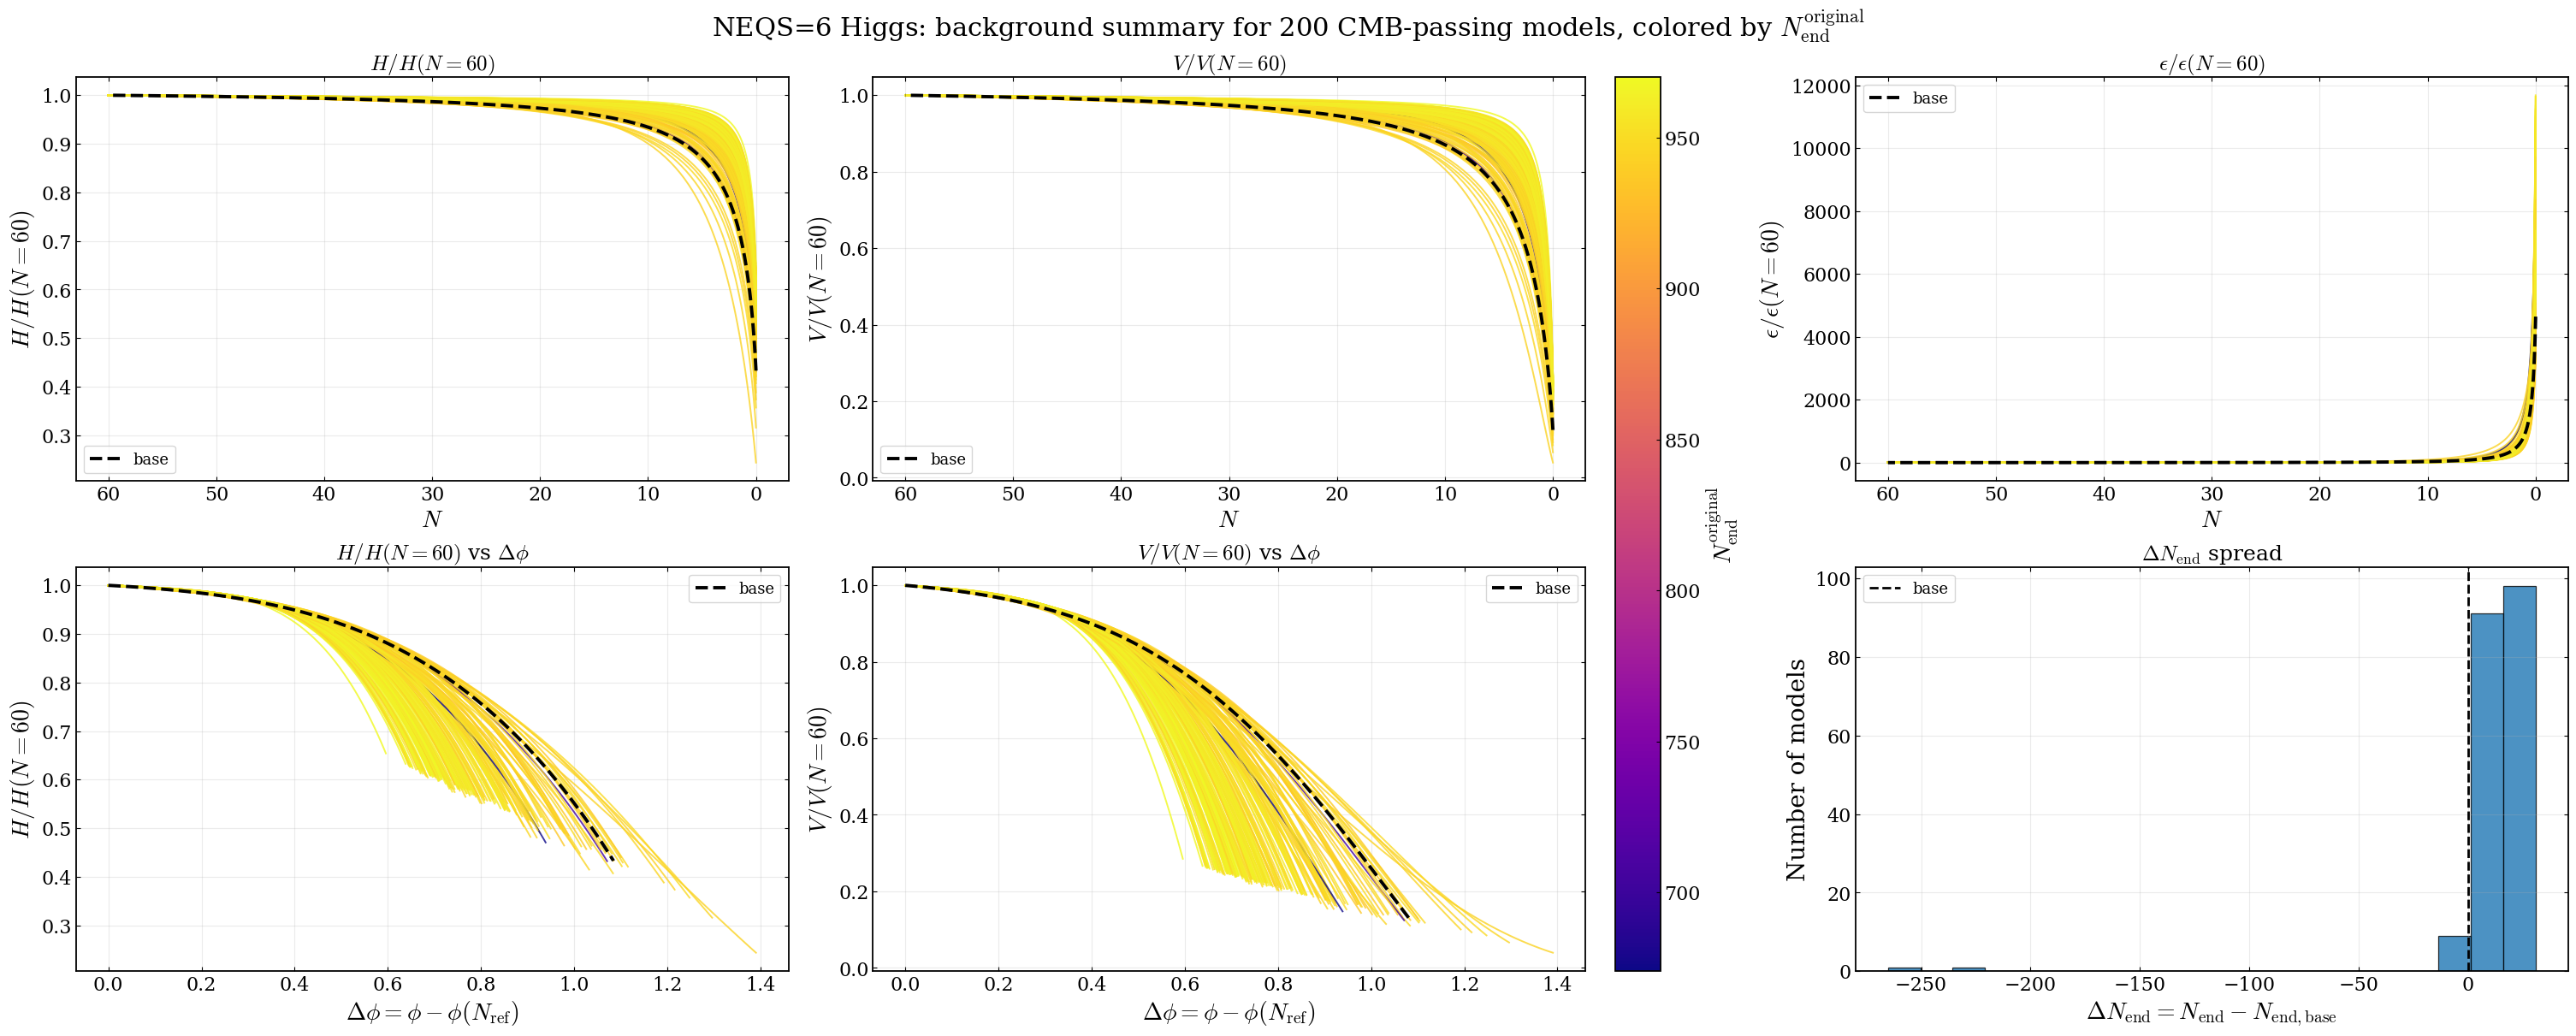


Higgs (NEQS=6)
Models plotted   : 200
Base N_end       : 939.163572
Median |deltaN|  : 16.009
Mean |deltaN|    : 17.757
Max |deltaN|     : 265.178


In [59]:
# ============================================================
# CELL 6: Combined background summary plot for CMB-passing models
#
# Panels: H(N), V(N), eps(N)  [normalized at N_ref]
#         H(phi), V(phi)      [normalized at N_ref, vs delta_phi]
#         deltaN spread histogram (N_end - N_end_base)
#
# Uses the `passing` DataFrame built in Cell 5 (CMB-cut models,
# with an `outdir` column pointing straight at each model's folder).
# ============================================================

plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
    "axes.labelsize": 20,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 13,
    "figure.titlesize": 22,
    "axes.linewidth": 1.3,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

NEQS = 6
model_tag = "higgs"
N_ref = 60.0


# --- Load one model's raw path file directly from its outdir -----------
def load_path_from_outdir(outdir, NEQS=NEQS):
    folder = Path(outdir)
    matches = list(
        folder.glob(f"path_neqs{NEQS}_lam2_*_lam3_*_lam4_*_lam5_*.dat")
    )
    if not matches:
        raise FileNotFoundError(f"No path file found in: {outdir}")
    return pd.read_csv(matches[0], sep=r"\s+", header=None).values


# --- Process one model's trajectory into everything the plot needs -----
def process_trajectory(data, N_ref=N_ref, NEQS=NEQS):
    """
    From raw path data, return N-aligned and phi-aligned normalized
    curves for H, V, and eps, all anchored at N_ref.
    """
    phi_raw = np.asarray(data[:, 0], dtype=float)
    H_raw = np.asarray(data[:, 1], dtype=float)
    eps_raw = np.asarray(data[:, 2], dtype=float)
    N_raw = np.asarray(data[:, NEQS], dtype=float)
    V_raw = np.asarray(data[:, NEQS + 1], dtype=float)

    finite = (
        np.isfinite(phi_raw)
        & np.isfinite(H_raw)
        & np.isfinite(eps_raw)
        & np.isfinite(N_raw)
        & np.isfinite(V_raw)
    )
    phi_raw, H_raw, eps_raw, N_raw, V_raw = (
        phi_raw[finite], H_raw[finite], eps_raw[finite], N_raw[finite], V_raw[finite]
    )

    if len(N_raw) < 2:
        raise ValueError("Not enough finite path points.")

    # Order everything consistently by N
    dN = np.diff(N_raw)
    if np.all(dN >= 0):
        N_use, phi_use, H_use, eps_use, V_use = N_raw, phi_raw, H_raw, eps_raw, V_raw
    elif np.all(dN <= 0):
        N_use = N_raw[::-1]
        phi_use = phi_raw[::-1]
        H_use = H_raw[::-1]
        eps_use = eps_raw[::-1]
        V_use = V_raw[::-1]
    else:
        raise ValueError("N is non-monotonic; refusing to reorder trajectory.")

    if not (N_use.min() <= N_ref <= N_use.max()):
        raise ValueError(
            f"N_ref={N_ref} outside range [{N_use.min():.4f}, {N_use.max():.4f}]"
        )

    # Reference values at N_ref
    phi_ref = np.interp(N_ref, N_use, phi_use)
    H_ref = np.interp(N_ref, N_use, H_use)
    eps_ref = np.interp(N_ref, N_use, eps_use)
    V_ref = np.interp(N_ref, N_use, V_use)

    if not (np.isfinite(H_ref) and abs(H_ref) > 1e-30):
        raise ValueError(f"Invalid H_ref at N_ref={N_ref}: {H_ref}")
    if not (np.isfinite(V_ref) and abs(V_ref) > 1e-30):
        raise ValueError(f"Invalid V_ref at N_ref={N_ref}: {V_ref}")
    if not (np.isfinite(eps_ref) and abs(eps_ref) > 1e-30):
        raise ValueError(f"Invalid eps_ref at N_ref={N_ref}: {eps_ref}")

    # N-aligned normalized curves
    H_norm_N = H_use / H_ref
    V_norm_N = V_use / V_ref
    eps_norm_N = eps_use / eps_ref

    # phi-aligned normalized curves
    delta_phi = phi_use - phi_ref
    H_norm_phi = H_use / H_ref
    V_norm_phi = V_use / V_ref

    dphi = np.diff(delta_phi)
    if np.all(dphi >= 0):
        pass
    elif np.all(dphi <= 0):
        delta_phi = delta_phi[::-1]
        H_norm_phi = H_norm_phi[::-1]
        V_norm_phi = V_norm_phi[::-1]
    else:
        raise ValueError("phi is non-monotonic; V(phi)/H(phi) would be multivalued.")

    return {
        "N": N_use,
        "H_norm_N": H_norm_N,
        "V_norm_N": V_norm_N,
        "eps_norm_N": eps_norm_N,
        "delta_phi": delta_phi,
        "H_norm_phi": H_norm_phi,
        "V_norm_phi": V_norm_phi,
    }


# --- Find the base model's row (for the black dashed overlay) -----------
base_val = MODEL_CONFIG[model_tag]["lam_base"][NEQS][1]
base_mask = np.isclose(
    summary_all["lam3"].to_numpy(dtype=float),
    base_val,
    rtol=1e-8,
    atol=max(1e-15, abs(base_val) * 1e-8),
)
base_row = summary_all.loc[base_mask].iloc[0]
base_N_end = float(base_row["original_N_end"])
base_curves = process_trajectory(load_path_from_outdir(base_row["outdir"]))

# --- Process every CMB-passing model ------------------------------------
processed = []
for _, row in passing.iterrows():
    try:
        data = load_path_from_outdir(row["outdir"])
        curves = process_trajectory(data)
        processed.append({
            **curves,
            "original_N_end": float(row["original_N_end"]),
            "deltaN_from_base": float(row["original_N_end"]) - base_N_end,
        })
    except (FileNotFoundError, ValueError) as e:
        print(f"Skipping {row['outdir']}: {e}")

print(f"Processed {len(processed)} / {len(passing)} CMB-passing models")

Nend_vals = np.array([m["original_N_end"] for m in processed])
cmap = plt.get_cmap("plasma")
norm = mcolors.Normalize(vmin=np.nanmin(Nend_vals), vmax=np.nanmax(Nend_vals))

# --- Build the 2x3 summary figure ----------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(30, 12), constrained_layout=True)
ax_HN, ax_VN, ax_epsN = axes[0]
ax_Hphi, ax_Vphi, ax_hist = axes[1]

for m in processed:
    color = cmap(norm(m["original_N_end"]))
    ax_HN.plot(m["N"], m["H_norm_N"], color=color, lw=1.4, alpha=0.8)
    ax_VN.plot(m["N"], m["V_norm_N"], color=color, lw=1.4, alpha=0.8)
    ax_epsN.plot(m["N"], m["eps_norm_N"], color=color, lw=1.4, alpha=0.8)
    ax_Hphi.plot(m["delta_phi"], m["H_norm_phi"], color=color, lw=1.4, alpha=0.8)
    ax_Vphi.plot(m["delta_phi"], m["V_norm_phi"], color=color, lw=1.4, alpha=0.8)

# base model overlay (black dashed) on all N/phi panels
ax_HN.plot(base_curves["N"], base_curves["H_norm_N"], color="black", lw=2.8, ls="--", label="base")
ax_VN.plot(base_curves["N"], base_curves["V_norm_N"], color="black", lw=2.8, ls="--", label="base")
ax_epsN.plot(base_curves["N"], base_curves["eps_norm_N"], color="black", lw=2.8, ls="--", label="base")
ax_Hphi.plot(base_curves["delta_phi"], base_curves["H_norm_phi"], color="black", lw=2.8, ls="--", label="base")
ax_Vphi.plot(base_curves["delta_phi"], base_curves["V_norm_phi"], color="black", lw=2.8, ls="--", label="base")

# deltaN histogram (no per-model color; it's an aggregate count, not a line)
deltaN_vals = np.array([m["deltaN_from_base"] for m in processed])
ax_hist.hist(deltaN_vals, bins=20, alpha=0.8, edgecolor="black", linewidth=0.9)
ax_hist.axvline(0.0, color="black", ls="--", lw=2.0, label="base")

# --- Titles / labels -----------------------------------------------------
ax_HN.set_title(rf"$H/H(N={N_ref:g})$")
ax_VN.set_title(rf"$V/V(N={N_ref:g})$")
ax_epsN.set_title(rf"$\epsilon/\epsilon(N={N_ref:g})$")
ax_Hphi.set_title(rf"$H/H(N={N_ref:g})$ vs $\Delta\phi$")
ax_Vphi.set_title(rf"$V/V(N={N_ref:g})$ vs $\Delta\phi$")
ax_hist.set_title(r"$\Delta N_{\rm end}$ spread")

for ax in [ax_HN, ax_VN, ax_epsN]:
    ax.set_xlabel(r"$N$")
    ax.invert_xaxis()

ax_HN.set_ylabel(rf"$H/H(N={N_ref:g})$")
ax_VN.set_ylabel(rf"$V/V(N={N_ref:g})$")
ax_epsN.set_ylabel(rf"$\epsilon/\epsilon(N={N_ref:g})$")

ax_Hphi.set_xlabel(r"$\Delta\phi=\phi-\phi(N_{\rm ref})$")
ax_Vphi.set_xlabel(r"$\Delta\phi=\phi-\phi(N_{\rm ref})$")
ax_Hphi.set_ylabel(rf"$H/H(N={N_ref:g})$")
ax_Vphi.set_ylabel(rf"$V/V(N={N_ref:g})$")

ax_hist.set_xlabel(r"$\Delta N_{\rm end}=N_{\rm end}-N_{\rm end,base}$")
ax_hist.set_ylabel("Number of models")

for ax in axes.ravel():
    ax.grid(True, alpha=0.25)
    handles, labels = ax.get_legend_handles_labels()
    if len(handles) > 0:
        ax.legend()

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[:, :2].ravel().tolist(), pad=0.02)
cbar.set_label(r"$N_{\rm end}^{\rm original}$")
cbar.ax.tick_params(direction="in")

# Force plain numbers (e.g. "946") instead of an offset/scientific notation
# (e.g. "+9.463e2") on the colorbar ticks.
cbar_formatter = ScalarFormatter(useOffset=False)
cbar_formatter.set_scientific(False)
cbar.formatter = cbar_formatter
cbar.update_ticks()

fig.suptitle(
    rf"NEQS={NEQS} {MODEL_CONFIG[model_tag]['label']}: "
    rf"background summary for {len(processed)} CMB-passing models, "
    r"colored by $N_{\rm end}^{\rm original}$"
)

fig.savefig(
    f"paper_{model_tag}_neqs{NEQS}_background_summary_colored_by_Nend.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# --- Console summary -------------------------------------------------------
print("\n" + "=" * 60)
print(f"{MODEL_CONFIG[model_tag]['label']} (NEQS={NEQS})")
print("=" * 60)
print(f"Models plotted   : {len(processed)}")
print(f"Base N_end       : {base_N_end:.6f}")
print(f"Median |deltaN|  : {np.median(np.abs(deltaN_vals)):.3f}")
print(f"Mean |deltaN|    : {np.mean(np.abs(deltaN_vals)):.3f}")
print(f"Max |deltaN|     : {np.max(np.abs(deltaN_vals)):.3f}")

# MOVE TO OMEGA_GW

In [42]:
def plot_shifted_omegaGW_batches(
    NEQS,
    base_path_root,
    tf_k_invMpc,
    tf_median,
    model_tag="higgs",
    h=0.67,
    k0=1.6e14,
    max_abs_deltaN=None,
    reference_outdir=None,
    reference_mask=None,
    cmap_name="plasma",
    color_column="original_N_end",
    alpha=0.65,
    lw=1.6,
    save_name=None,
    show=True,
):
    """
    Compute and plot transferred Omega_GW spectra for every accepted model
    found across the batch summary files.

    Parameters
    ----------
    reference_outdir
        Exact outdir of the model used as the Delta-N reference.

    reference_mask
        Optional Boolean mask defined on summary_all. Use this to select
        the reference model from its seed parameters when reference_outdir
        is not supplied.

    Assumed transfer convention
    ---------------------------
    Omega_GW h^2 = T(k) * P_t(k)
    """

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    # ------------------------------------------------------------
    # 1. Load all accepted models from all batches
    # ------------------------------------------------------------
    summary_all = load_batch_summaries(
        NEQS,
        base_path_root,
        model_tag=model_tag,
    ).copy()

    if summary_all.empty:
        raise ValueError(
            f"No accepted NEQS={NEQS} models were found."
        )

    if "outdir" not in summary_all.columns:
        raise ValueError(
            "Summary table does not contain an 'outdir' column."
        )

    if "original_N_end" not in summary_all.columns:
        raise ValueError(
            "Summary table does not contain 'original_N_end'."
        )

    # ------------------------------------------------------------
    # 2. Choose the reference model
    # ------------------------------------------------------------
    if reference_outdir is not None:
        reference_rows = summary_all.loc[
            summary_all["outdir"].astype(str) == str(reference_outdir)
        ]

    elif reference_mask is not None:
        reference_rows = summary_all.loc[reference_mask]

    else:
        raise ValueError(
            "Provide either reference_outdir or reference_mask."
        )

    if len(reference_rows) == 0:
        raise ValueError("Reference model was not found.")

    if len(reference_rows) > 1:
        print(
            f"WARNING: {len(reference_rows)} reference matches found; "
            "using the first."
        )

    reference_row = reference_rows.iloc[0]
    reference_N_end = float(reference_row["original_N_end"])
    reference_outdir_used = str(reference_row["outdir"])

    print("Reference model:")
    print(f"  outdir          = {reference_outdir_used}")
    print(f"  original_N_end  = {reference_N_end:.10f}")

    # ------------------------------------------------------------
    # 3. Prepare the transfer function
    # ------------------------------------------------------------
    tf_k = np.asarray(tf_k_invMpc, dtype=float)
    tf_T = np.asarray(tf_median, dtype=float)

    good_tf = (
        np.isfinite(tf_k)
        & np.isfinite(tf_T)
        & (tf_k > 0.0)
        & (tf_T > 0.0)
    )

    n_bad_tf = np.count_nonzero(~good_tf)

    if n_bad_tf > 0:
        raise ValueError(
            f"Transfer function contains {n_bad_tf} invalid points."
        )

    order_tf = np.argsort(tf_k)
    tf_k = tf_k[order_tf]
    tf_T = tf_T[order_tf]

    # Remove duplicate k-values because interpolation expects an
    # unambiguous increasing coordinate.
    tf_k, unique_indices = np.unique(tf_k, return_index=True)
    tf_T = tf_T[unique_indices]

    if len(tf_k) < 2:
        raise ValueError(
            "Transfer function needs at least two valid k-points."
        )

    logT_interp = interp1d(
        np.log(tf_k),
        np.log(tf_T),
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    kmin_tf = tf_k.min()
    kmax_tf = tf_k.max()

    print("\nTransfer-function range:")
    print(f"  k_min = {kmin_tf:.6e} Mpc^-1")
    print(f"  k_max = {kmax_tf:.6e} Mpc^-1")

    # ------------------------------------------------------------
    # 4. Set up plot coloring
    # ------------------------------------------------------------
    color_values = summary_all[color_column].to_numpy(dtype=float)

    finite_color = np.isfinite(color_values)
    if not np.any(finite_color):
        raise ValueError(
            f"No finite values found in color column '{color_column}'."
        )

    color_min = np.nanmin(color_values)
    color_max = np.nanmax(color_values)

    # Normalize needs nonzero width.
    if np.isclose(color_min, color_max):
        color_min -= 0.5
        color_max += 0.5

    cmap = plt.get_cmap(cmap_name)
    norm = mcolors.Normalize(
        vmin=color_min,
        vmax=color_max,
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, 6.5),
        constrained_layout=True,
    )

    ax_h2, ax_plain = axes

    rows = []

    n_total = 0
    n_kept = 0
    n_rejected_deltaN = 0
    n_rejected_overlap = 0
    n_rejected_invalid = 0
    n_rejected_missing = 0

    # ------------------------------------------------------------
    # 5. Process every accepted batch model
    # ------------------------------------------------------------
    for _, row in summary_all.iterrows():
        n_total += 1

        outdir = str(row["outdir"])

        try:
            model_N_end = float(row["original_N_end"])

            if not np.isfinite(model_N_end):
                raise ValueError("original_N_end is non-finite.")

            deltaN = model_N_end - reference_N_end
            abs_deltaN = abs(deltaN)

            if (
                max_abs_deltaN is not None
                and abs_deltaN > max_abs_deltaN
            ):
                n_rejected_deltaN += 1
                continue

            tensor_file = os.path.join(
                outdir,
                f"spec_t_neqs{NEQS}.dat",
            )

            tensor_data = np.loadtxt(tensor_file)

            if tensor_data.ndim != 2 or tensor_data.shape[1] < 2:
                raise ValueError(
                    "Tensor spectrum file must have at least two columns."
                )

            k_t_raw = np.asarray(tensor_data[:, 0], dtype=float)
            Pt_raw = np.asarray(tensor_data[:, 1], dtype=float)

            # Strictly reject invalid raw tensor points.
            valid_raw = (
                np.isfinite(k_t_raw)
                & np.isfinite(Pt_raw)
                & (k_t_raw > 0.0)
                & (Pt_raw > 0.0)
            )

            if not np.all(valid_raw):
                n_bad = np.count_nonzero(~valid_raw)
                raise ValueError(
                    f"Tensor spectrum contains {n_bad} invalid rows."
                )

            order = np.argsort(k_t_raw)
            k_t_raw = k_t_raw[order]
            Pt_raw = Pt_raw[order]

            # Shift the tensor-spectrum k-grid.
            k_t_shifted = k_t_raw * np.exp(-deltaN)

            # Only use the region covered by the transfer function.
            overlap = (
                (k_t_shifted >= kmin_tf)
                & (k_t_shifted <= kmax_tf)
            )

            if np.count_nonzero(overlap) < 5:
                n_rejected_overlap += 1
                print(
                    f"[skip overlap] {outdir}: "
                    f"only {np.count_nonzero(overlap)} points "
                    "inside the transfer-function range."
                )
                continue

            k_use = k_t_shifted[overlap]
            Pt_use = Pt_raw[overlap]

            # Interpolate in log(k)-log(T), appropriate for a large
            # dynamic range and positive transfer function.
            logT_use = logT_interp(np.log(k_use))
            T_use = np.exp(logT_use)

            valid_tf_interp = (
                np.isfinite(T_use)
                & (T_use > 0.0)
            )

            if not np.all(valid_tf_interp):
                n_bad = np.count_nonzero(~valid_tf_interp)
                raise ValueError(
                    f"Transfer interpolation produced {n_bad} invalid values."
                )

            # Current transfer-function convention.
            OmegaGW_h2 = T_use * Pt_use
            OmegaGW = OmegaGW_h2 / h**2

            color_value = float(row[color_column])
            color = cmap(norm(color_value))

            ax_h2.loglog(
                k_use,
                OmegaGW_h2,
                color=color,
                lw=lw,
                alpha=alpha,
            )

            ax_plain.loglog(
                k_use,
                OmegaGW,
                color=color,
                lw=lw,
                alpha=alpha,
            )

            # Only report k0 if it lies inside this model's usable range.
            k0_in_range = k_use.min() <= k0 <= k_use.max()

            if k0_in_range:
                # Log-space nearest point is more appropriate across
                # many orders of magnitude.
                j0 = np.argmin(
                    np.abs(np.log(k_use) - np.log(k0))
                )

                k_nearest_k0 = k_use[j0]
                omega_h2_k0 = OmegaGW_h2[j0]
                omega_k0 = OmegaGW[j0]

                ax_h2.scatter(
                    k_nearest_k0,
                    omega_h2_k0,
                    s=22,
                    color="crimson",
                    alpha=0.45,
                    zorder=5,
                )

                ax_plain.scatter(
                    k_nearest_k0,
                    omega_k0,
                    s=22,
                    color="crimson",
                    alpha=0.45,
                    zorder=5,
                )

            else:
                k_nearest_k0 = np.nan
                omega_h2_k0 = np.nan
                omega_k0 = np.nan

            result = {
                "outdir": outdir,
                "original_N_end": model_N_end,
                "reference_N_end": reference_N_end,
                "deltaN_from_reference": deltaN,
                "abs_deltaN_from_reference": abs_deltaN,
                "max_abs_deltaN_cut": max_abs_deltaN,
                "k_min_used": k_use.min(),
                "k_max_used": k_use.max(),
                "n_k_points_used": len(k_use),
                "k0_in_range": k0_in_range,
                "k_nearest_k0": k_nearest_k0,
                "OmegaGW_h2_at_k0": omega_h2_k0,
                "OmegaGW_at_k0": omega_k0,
                "OmegaGW_h2_min": np.min(OmegaGW_h2),
                "OmegaGW_h2_max": np.max(OmegaGW_h2),
                "OmegaGW_min": np.min(OmegaGW),
                "OmegaGW_max": np.max(OmegaGW),
            }

            # Preserve useful sampled hierarchy values in output.
            for column in [
                "eps",
                "sig",
                "lam2",
                "lam3",
                "lam4",
                "lam5",
                "n_s",
                "r",
                "alpha_s",
            ]:
                if column in row.index:
                    result[column] = row[column]

            rows.append(result)
            n_kept += 1

        except FileNotFoundError:
            n_rejected_missing += 1
            print(f"[missing] Tensor spectrum not found for: {outdir}")

        except (ValueError, OSError) as e:
            n_rejected_invalid += 1
            print(f"[invalid] {outdir}: {e}")

    # ------------------------------------------------------------
    # 6. Finish plot
    # ------------------------------------------------------------
    for ax in axes:
        ax.axvline(
            k0,
            color="crimson",
            linestyle="--",
            lw=2.0,
            alpha=0.85,
            label=(
                rf"$k_0={k0:.2e}\,"
                rf"{{\rm Mpc}}^{{-1}}$"
            ),
        )

        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()
        ax.legend(frameon=False, loc="best")

    ax_h2.set_title(
        r"Transferred shifted tensor spectra"
    )
    ax_plain.set_title(
        r"Transferred shifted tensor spectra"
    )

    ax_h2.set_xlabel(
        r"$k_{\rm shifted}\ [{\rm Mpc}^{-1}]$"
    )
    ax_plain.set_xlabel(
        r"$k_{\rm shifted}\ [{\rm Mpc}^{-1}]$"
    )

    ax_h2.set_ylabel(r"$\Omega_{\rm GW}h^2(k)$")
    ax_plain.set_ylabel(r"$\Omega_{\rm GW}(k)$")

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes,
        pad=0.02,
        fraction=0.035,
    )
    cbar.set_label(color_column, fontsize=18)
    cbar.ax.tick_params(labelsize=14, direction="in")

    cut_text = ""
    if max_abs_deltaN is not None:
        cut_text = (
            rf", $|\Delta N|\leq {max_abs_deltaN}$"
        )

    fig.suptitle(
        rf"NEQS={NEQS} {model_tag}: "
        rf"transferred $\Omega_{{\rm GW}}$"
        rf"{cut_text}",
        fontsize=22,
    )

    if save_name is None:
        save_name = (
            f"neqs{NEQS}_{model_tag}_batch_"
            f"shifted_omegaGW.pdf"
        )

    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    omega_df = pd.DataFrame(rows)

    print("\n=== Shifted OmegaGW filtering summary ===")
    print(f"Total accepted models read : {n_total}")
    print(f"Kept models                : {n_kept}")
    print(f"Rejected by |deltaN|       : {n_rejected_deltaN}")
    print(f"Rejected by TF overlap     : {n_rejected_overlap}")
    print(f"Missing spectrum files     : {n_rejected_missing}")
    print(f"Rejected invalid data      : {n_rejected_invalid}")

    if not omega_df.empty:
        print("\n=== OmegaGW summary ===")
        display_cols = [
            "original_N_end",
            "deltaN_from_reference",
            "k_min_used",
            "k_max_used",
            "OmegaGW_h2_at_k0",
            "OmegaGW_at_k0",
        ]

        print(
            omega_df[display_cols].to_string(index=False)
        )

    return omega_df

Reference model:
  outdir          = /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch001/lam2_2.7897200000e-04_lam3_-4.6097100000e-06_lam4_0.0000000000e+00_lam5_0.0000000000e+00
  original_N_end  = 939.1635722724

Transfer-function range:
  k_min = 6.175630e+05 Mpc^-1
  k_max = 7.178160e+18 Mpc^-1
[skip overlap] /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch001/lam2_6.2412951707e-04_lam3_-7.2571854744e-05_lam4_0.0000000000e+00_lam5_0.0000000000e+00: only 3 points inside the transfer-function range.
[skip overlap] /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch001/lam2_9.0619281482e-04_lam3_-8.4809288851e-05_lam4_0.0000000000e+00_lam5_0.0000000000e+00: only 2 points inside the transfer-function 

[skip overlap] /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch004/lam2_6.9597222157e-04_lam3_-6.0410162055e-05_lam4_0.0000000000e+00_lam5_0.0000000000e+00: only 4 points inside the transfer-function range.
[skip overlap] /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch004/lam2_7.8929542647e-04_lam3_-6.9279633446e-05_lam4_0.0000000000e+00_lam5_0.0000000000e+00: only 3 points inside the transfer-function range.
[skip overlap] /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch004/lam2_6.5414119384e-04_lam3_-6.0969763395e-05_lam4_0.0000000000e+00_lam5_0.0000000000e+00: only 4 points inside the transfer-function range.
[skip overlap] /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/infla

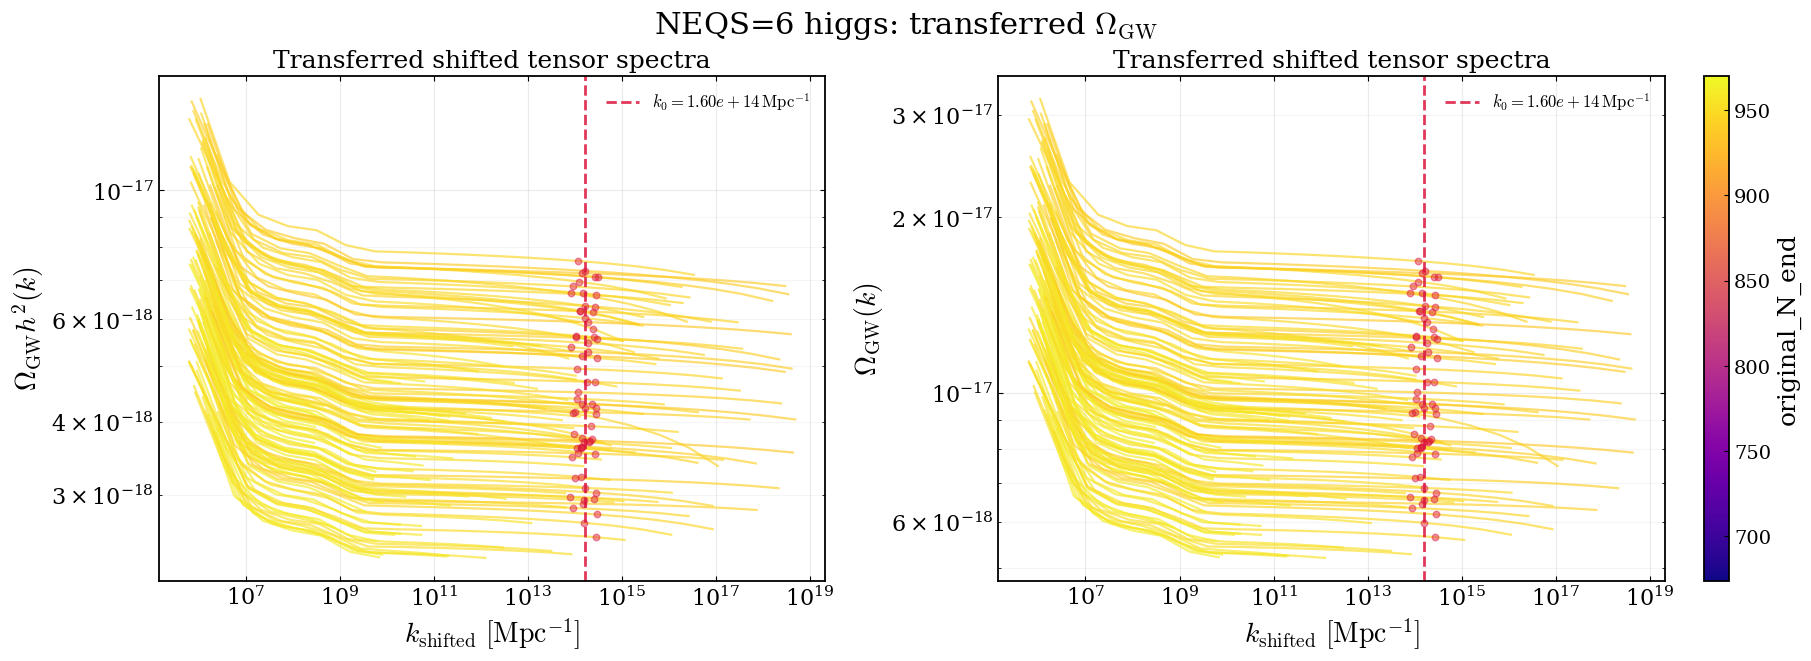


=== Shifted OmegaGW filtering summary ===
Total accepted models read : 186
Kept models                : 148
Rejected by |deltaN|       : 0
Rejected by TF overlap     : 38
Missing spectrum files     : 0
Rejected invalid data      : 0

=== OmegaGW summary ===
 original_N_end  deltaN_from_reference   k_min_used   k_max_used  OmegaGW_h2_at_k0  OmegaGW_at_k0
     939.163572               0.000000 1.006212e+06 2.230127e+18      5.617352e-18   1.251359e-17
     945.027875               5.864303 8.413621e+05 2.622873e+16      2.849299e-18   6.347292e-18
     948.900227               9.736655 1.244767e+06 5.458033e+14      3.218791e-18   7.170395e-18
     960.371883              21.208310 1.125298e+06 5.687999e+09               NaN            NaN
     952.458528              13.294956 2.521062e+06 1.554840e+13               NaN            NaN
     959.175331              20.011759 8.987544e+05 1.881980e+10               NaN            NaN
     949.604582              10.441010 2.549603e+06 2.6

In [47]:
omega6_df = plot_shifted_omegaGW_batches(
    NEQS=6,
    base_path_root=base_path_root,
    tf_k_invMpc=tf_k_invMpc,
    tf_median=tf_median,
    model_tag="higgs",
    h=0.67,
    k0=1.6e14,
    max_abs_deltaN=None,
    reference_mask=base_mask,
    color_column="original_N_end",
    cmap_name="plasma",
    save_name="neqs6_higgs_batches_shifted_omegaGW_dN10.pdf",
)

Regardless of Nend:

In [44]:
def plot_all_omegaGW_batches_purple(
    NEQS,
    base_path_root,
    tf_k_invMpc,
    tf_median,
    model_tag="higgs",
    h=0.67,
    k0=1.6e14,

    # Reference-model seed values
    reference_eps=0.000209237,
    reference_sig=-0.0342419,
    reference_lam2=0.000278972,
    reference_lam3=-4.60971e-6,

    line_color="mediumpurple",
    reference_color="indigo",
    marker_color="darkviolet",

    alpha=0.45,
    lw=1.4,
    reference_lw=3.2,

    min_overlap_points=5,
    save_name=None,
    show=True,
):
    """
    Apply the transfer function to the raw tensor spectrum of every
    accepted model found across all batches.

    All accepted models are plotted.
    No original_N_end cut is applied.
    No Delta-N shift is applied.

    The base/reference model is identified using its N=60 seed values
    in the combined summary table and highlighted with a thicker line.

    Transfer convention
    -------------------
    Omega_GW h^2(k) = T(k) * P_t(k)
    Omega_GW(k)     = Omega_GW h^2(k) / h^2
    """

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    # ============================================================
    # 1. Load all accepted models across all batches
    # ============================================================
    summary_all = load_batch_summaries(
        NEQS,
        base_path_root,
        model_tag=model_tag,
    ).copy()

    if summary_all.empty:
        raise ValueError(
            f"No accepted NEQS={NEQS} {model_tag} models were found."
        )

    if "outdir" not in summary_all.columns:
        raise ValueError(
            "The combined summary table does not contain an 'outdir' column."
        )

    required_reference_columns = [
        "eps",
        "sig",
        "lam2",
        "lam3",
    ]

    missing_reference_columns = [
        col for col in required_reference_columns
        if col not in summary_all.columns
    ]

    if missing_reference_columns:
        raise ValueError(
            "Cannot identify the reference model because the summary "
            "is missing columns: "
            + ", ".join(missing_reference_columns)
        )

    print(f"Accepted models found: {len(summary_all)}")

    # ============================================================
    # 2. Identify the reference model
    # ============================================================
    reference_mask = (
        np.isclose(
            summary_all["eps"].to_numpy(dtype=float),
            reference_eps,
            rtol=1e-8,
            atol=max(1e-15, abs(reference_eps) * 1e-8),
        )
        &
        np.isclose(
            summary_all["sig"].to_numpy(dtype=float),
            reference_sig,
            rtol=1e-8,
            atol=max(1e-15, abs(reference_sig) * 1e-8),
        )
        &
        np.isclose(
            summary_all["lam2"].to_numpy(dtype=float),
            reference_lam2,
            rtol=1e-8,
            atol=max(1e-15, abs(reference_lam2) * 1e-8),
        )
        &
        np.isclose(
            summary_all["lam3"].to_numpy(dtype=float),
            reference_lam3,
            rtol=1e-8,
            atol=max(1e-15, abs(reference_lam3) * 1e-8),
        )
    )

    reference_matches = summary_all.loc[reference_mask]

    if len(reference_matches) == 0:
        raise ValueError(
            "Could not identify the reference model from the supplied "
            "eps, sig, lam2, and lam3 seed values."
        )

    if len(reference_matches) > 1:
        print(
            f"WARNING: found {len(reference_matches)} reference-model "
            "matches; using the first."
        )

    reference_row = reference_matches.iloc[0]
    reference_outdir = os.path.normpath(str(reference_row["outdir"]))

    print("\nReference model identified:")
    print(f"  eps    = {float(reference_row['eps']):.10e}")
    print(f"  sig    = {float(reference_row['sig']):.10e}")
    print(f"  lam2   = {float(reference_row['lam2']):.10e}")
    print(f"  lam3   = {float(reference_row['lam3']):.10e}")
    print(f"  outdir = {reference_outdir}")

    # ============================================================
    # 3. Validate and prepare the transfer function
    # ============================================================
    tf_k = np.asarray(tf_k_invMpc, dtype=float)
    tf_T = np.asarray(tf_median, dtype=float)

    if tf_k.shape != tf_T.shape:
        raise ValueError(
            "tf_k_invMpc and tf_median must have matching shapes."
        )

    valid_tf = (
        np.isfinite(tf_k)
        & np.isfinite(tf_T)
        & (tf_k > 0.0)
        & (tf_T > 0.0)
    )

    n_bad_tf = np.count_nonzero(~valid_tf)

    if n_bad_tf > 0:
        raise ValueError(
            f"Transfer function contains {n_bad_tf} invalid rows."
        )

    order_tf = np.argsort(tf_k)
    tf_k = tf_k[order_tf]
    tf_T = tf_T[order_tf]

    tf_k, unique_indices = np.unique(
        tf_k,
        return_index=True,
    )
    tf_T = tf_T[unique_indices]

    if len(tf_k) < 2:
        raise ValueError(
            "Transfer function requires at least two distinct k points."
        )

    logT_interp = interp1d(
        np.log(tf_k),
        np.log(tf_T),
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    kmin_tf = float(tf_k.min())
    kmax_tf = float(tf_k.max())

    print("\nTransfer-function range:")
    print(f"  k_min = {kmin_tf:.6e} Mpc^-1")
    print(f"  k_max = {kmax_tf:.6e} Mpc^-1")

    # ============================================================
    # 4. Set up the plot
    # ============================================================
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, 6.5),
        constrained_layout=True,
    )

    ax_h2, ax_plain = axes

    result_rows = []

    n_total = len(summary_all)
    n_kept = 0
    n_missing = 0
    n_invalid = 0
    n_no_overlap = 0
    n_k0_covered = 0

    reference_plotted = False

    # ============================================================
    # 5. Process every model
    # ============================================================
    for model_index, (_, row) in enumerate(
        summary_all.iterrows(),
        start=1,
    ):
        outdir = str(row["outdir"])
        normalized_outdir = os.path.normpath(outdir)

        is_reference = normalized_outdir == reference_outdir

        try:
            tensor_file = os.path.join(
                outdir,
                f"spec_t_neqs{NEQS}.dat",
            )

            tensor_data = np.loadtxt(tensor_file)

            if tensor_data.ndim != 2 or tensor_data.shape[1] < 2:
                raise ValueError(
                    "Tensor spectrum file must contain at least two columns."
                )

            k_t = np.asarray(
                tensor_data[:, 0],
                dtype=float,
            )

            Pt = np.asarray(
                tensor_data[:, 1],
                dtype=float,
            )

            valid_tensor = (
                np.isfinite(k_t)
                & np.isfinite(Pt)
                & (k_t > 0.0)
                & (Pt > 0.0)
            )

            if not np.all(valid_tensor):
                n_bad = np.count_nonzero(~valid_tensor)

                raise ValueError(
                    f"Tensor spectrum contains {n_bad} invalid rows."
                )

            tensor_order = np.argsort(k_t)
            k_t = k_t[tensor_order]
            Pt = Pt[tensor_order]

            k_t, unique_tensor_indices = np.unique(
                k_t,
                return_index=True,
            )
            Pt = Pt[unique_tensor_indices]

            # Raw saved k-grid; no Delta-N shift.
            overlap = (
                (k_t >= kmin_tf)
                & (k_t <= kmax_tf)
            )

            n_overlap = np.count_nonzero(overlap)

            if n_overlap < min_overlap_points:
                n_no_overlap += 1

                print(
                    f"[skip overlap] {outdir}: "
                    f"only {n_overlap} tensor points within TF range."
                )
                continue

            k_use = k_t[overlap]
            Pt_use = Pt[overlap]

            logT_use = logT_interp(np.log(k_use))
            T_use = np.exp(logT_use)

            valid_interpolation = (
                np.isfinite(T_use)
                & (T_use > 0.0)
            )

            if not np.all(valid_interpolation):
                n_bad = np.count_nonzero(~valid_interpolation)

                raise ValueError(
                    f"Transfer interpolation produced {n_bad} invalid values."
                )

            OmegaGW_h2 = T_use * Pt_use
            OmegaGW = OmegaGW_h2 / h**2

            if not (
                np.all(np.isfinite(OmegaGW_h2))
                and np.all(OmegaGW_h2 > 0.0)
                and np.all(np.isfinite(OmegaGW))
                and np.all(OmegaGW > 0.0)
            ):
                raise ValueError(
                    "Computed OmegaGW contains invalid values."
                )

            # ----------------------------------------------------
            # Plot style: ordinary model versus reference model
            # ----------------------------------------------------
            if is_reference:
                plot_color = reference_color
                plot_lw = reference_lw
                plot_alpha = 1.0
                plot_zorder = 10
                plot_label = "Reference model"
                reference_plotted = True
            else:
                plot_color = line_color
                plot_lw = lw
                plot_alpha = alpha
                plot_zorder = 2
                plot_label = None

            ax_h2.loglog(
                k_use,
                OmegaGW_h2,
                color=plot_color,
                lw=plot_lw,
                alpha=plot_alpha,
                zorder=plot_zorder,
                label=plot_label,
            )

            ax_plain.loglog(
                k_use,
                OmegaGW,
                color=plot_color,
                lw=plot_lw,
                alpha=plot_alpha,
                zorder=plot_zorder,
                label=plot_label,
            )

            # ----------------------------------------------------
            # Evaluate nearest saved point to k0
            # ----------------------------------------------------
            k0_in_range = k_use.min() <= k0 <= k_use.max()

            if k0_in_range:
                j0 = np.argmin(
                    np.abs(np.log(k_use) - np.log(k0))
                )

                k_nearest_k0 = float(k_use[j0])
                omega_h2_k0 = float(OmegaGW_h2[j0])
                omega_k0 = float(OmegaGW[j0])

                point_size = 42 if is_reference else 18
                point_alpha = 1.0 if is_reference else 0.40
                point_zorder = 12 if is_reference else 5

                ax_h2.scatter(
                    k_nearest_k0,
                    omega_h2_k0,
                    s=point_size,
                    color=marker_color,
                    alpha=point_alpha,
                    edgecolor="none",
                    zorder=point_zorder,
                )

                ax_plain.scatter(
                    k_nearest_k0,
                    omega_k0,
                    s=point_size,
                    color=marker_color,
                    alpha=point_alpha,
                    edgecolor="none",
                    zorder=point_zorder,
                )

                n_k0_covered += 1

            else:
                k_nearest_k0 = np.nan
                omega_h2_k0 = np.nan
                omega_k0 = np.nan

            result = {
                "model_index": model_index,
                "outdir": outdir,
                "is_reference": bool(is_reference),

                "k_min_used": float(k_use.min()),
                "k_max_used": float(k_use.max()),
                "n_k_points_used": int(len(k_use)),

                "k0_in_range": bool(k0_in_range),
                "k_nearest_k0": k_nearest_k0,

                "OmegaGW_h2_at_k0": omega_h2_k0,
                "OmegaGW_at_k0": omega_k0,

                "OmegaGW_h2_min": float(np.min(OmegaGW_h2)),
                "OmegaGW_h2_max": float(np.max(OmegaGW_h2)),

                "OmegaGW_min": float(np.min(OmegaGW)),
                "OmegaGW_max": float(np.max(OmegaGW)),
            }

            for column in [
                "eps",
                "sig",
                "lam2",
                "lam3",
                "lam4",
                "lam5",
                "n_s",
                "r",
                "alpha_s",
                "original_N_end",
            ]:
                if column in row.index:
                    result[column] = row[column]

            result_rows.append(result)
            n_kept += 1

        except FileNotFoundError:
            n_missing += 1

            print(
                f"[missing] Tensor spectrum not found for:\n{outdir}"
            )

        except (ValueError, OSError) as e:
            n_invalid += 1

            print(
                f"[invalid] {outdir}: {e}"
            )

    # ============================================================
    # 6. Confirm that the reference actually made it onto the plot
    # ============================================================
    if not reference_plotted:
        print(
            "\nWARNING: the reference model was identified in the summary "
            "but was not plotted. Check its tensor spectrum file, validity, "
            "and overlap with the transfer-function range."
        )

    # ============================================================
    # 7. Finish the plot
    # ============================================================
    for ax in axes:
        ax.axvline(
            k0,
            color=marker_color,
            linestyle="--",
            lw=2.0,
            alpha=0.85,
            label=(
                rf"$k_0={k0:.2e}\,"
                rf"{{\rm Mpc}}^{{-1}}$"
            ),
        )

        ax.grid(
            True,
            which="major",
            alpha=0.25,
        )

        ax.grid(
            True,
            which="minor",
            alpha=0.12,
        )

        ax.minorticks_on()

        ax.legend(
            frameon=False,
            loc="best",
        )

    ax_h2.set_title(
        r"All transferred tensor spectra"
    )

    ax_plain.set_title(
        r"All transferred tensor spectra"
    )

    ax_h2.set_xlabel(
        r"$k\ [{\rm Mpc}^{-1}]$"
    )

    ax_plain.set_xlabel(
        r"$k\ [{\rm Mpc}^{-1}]$"
    )

    ax_h2.set_ylabel(
        r"$\Omega_{\rm GW}h^2(k)$"
    )

    ax_plain.set_ylabel(
        r"$\Omega_{\rm GW}(k)$"
    )

    fig.suptitle(
        rf"NEQS={NEQS} {model_tag}: "
        rf"transferred $\Omega_{{\rm GW}}$ for all accepted models",
        fontsize=22,
    )

    if save_name is None:
        save_name = (
            f"neqs{NEQS}_{model_tag}_"
            f"all_models_omegaGW_reference.pdf"
        )

    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    omega_df = pd.DataFrame(result_rows)

    # ============================================================
    # 8. Report what happened
    # ============================================================
    print("\n=== All-model OmegaGW summary ===")
    print(f"Accepted models read       : {n_total}")
    print(f"Successfully plotted       : {n_kept}")
    print(f"Reference model plotted    : {reference_plotted}")
    print(f"Covering k0                : {n_k0_covered}")
    print(f"Insufficient TF overlap    : {n_no_overlap}")
    print(f"Missing spectrum files     : {n_missing}")
    print(f"Rejected invalid data      : {n_invalid}")

    if not omega_df.empty:
        print("\nOmegaGW range over all plotted models:")

        print(
            "  min OmegaGW h^2 = "
            f"{omega_df['OmegaGW_h2_min'].min():.6e}"
        )

        print(
            "  max OmegaGW h^2 = "
            f"{omega_df['OmegaGW_h2_max'].max():.6e}"
        )

        reference_results = omega_df.loc[
            omega_df["is_reference"]
        ]

        if not reference_results.empty:
            print("\nReference-model OmegaGW result:")

            print(
                reference_results[[
                    "eps",
                    "sig",
                    "lam2",
                    "lam3",
                    "k_min_used",
                    "k_max_used",
                    "OmegaGW_h2_at_k0",
                    "OmegaGW_at_k0",
                ]].to_string(index=False)
            )

    return omega_df

Accepted models found: 186

Reference model identified:
  eps    = 2.0923700000e-04
  sig    = -3.4241900000e-02
  lam2   = 2.7897200000e-04
  lam3   = -4.6097100000e-06
  outdir = /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch001/lam2_2.7897200000e-04_lam3_-4.6097100000e-06_lam4_0.0000000000e+00_lam5_0.0000000000e+00

Transfer-function range:
  k_min = 6.175630e+05 Mpc^-1
  k_max = 7.178160e+18 Mpc^-1


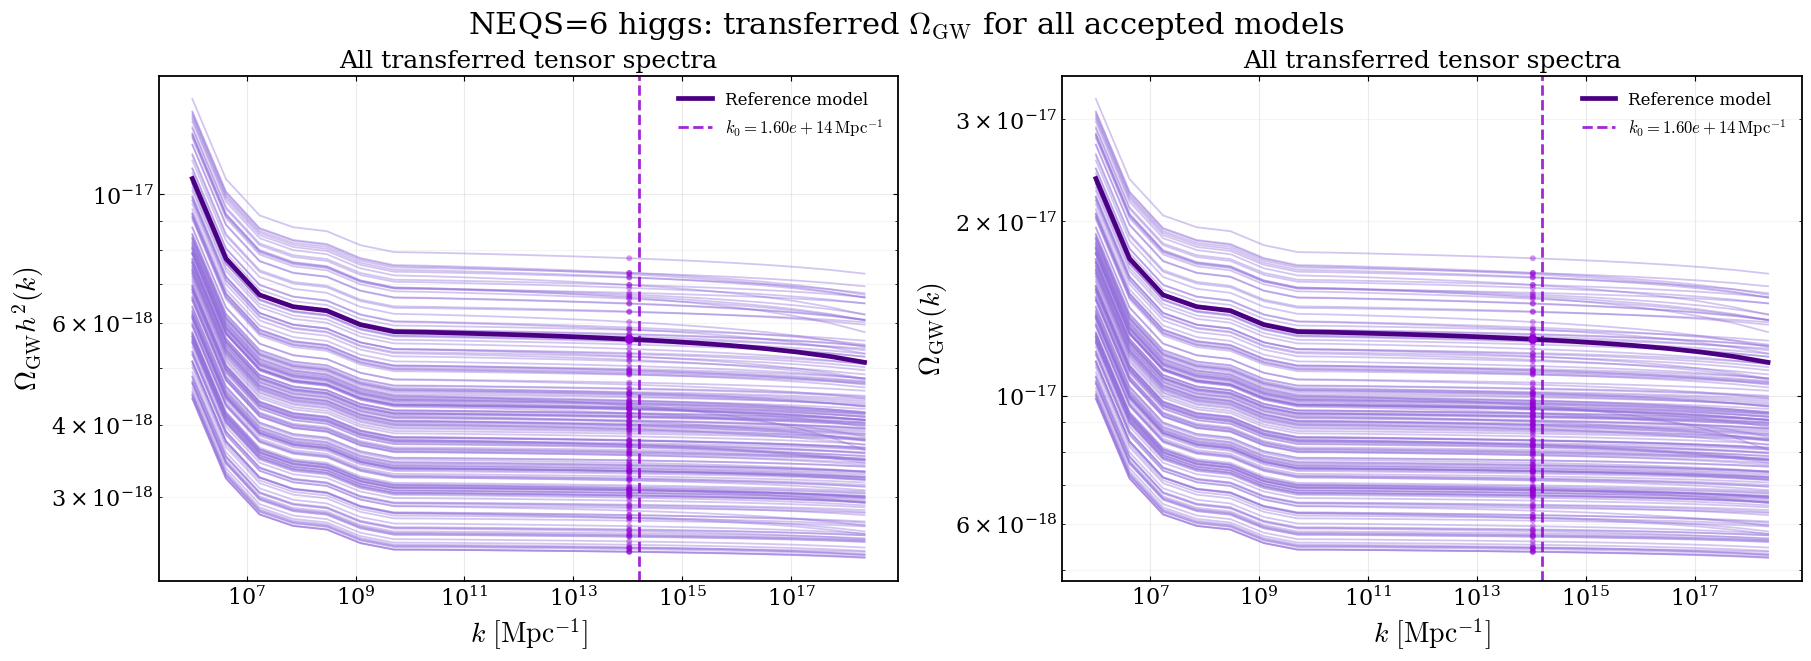


=== All-model OmegaGW summary ===
Accepted models read       : 186
Successfully plotted       : 186
Reference model plotted    : True
Covering k0                : 186
Insufficient TF overlap    : 0
Missing spectrum files     : 0
Rejected invalid data      : 0

OmegaGW range over all plotted models:
  min OmegaGW h^2 = 2.353117e-18
  max OmegaGW h^2 = 1.461147e-17

Reference-model OmegaGW result:
     eps       sig     lam2      lam3   k_min_used   k_max_used  OmegaGW_h2_at_k0  OmegaGW_at_k0
0.000209 -0.034242 0.000279 -0.000005 1.006212e+06 2.230127e+18      5.617352e-18   1.251359e-17


In [46]:
omega6_all_df = plot_all_omegaGW_batches_purple(
    NEQS=6,
    base_path_root=base_path_root,
    tf_k_invMpc=tf_k_invMpc,
    tf_median=tf_median,
    model_tag="higgs",
    h=0.67,
    k0=1.6e14,
    line_color="mediumpurple",
    reference_color="indigo",
    marker_color="darkviolet",
    alpha=0.40,
    lw=1.3,
    reference_lw=3.4,
    save_name="neqs6_higgs_all_models_omegaGW_reference.pdf",
)

If i want the threshold of ref or higher?????

In [48]:
def plot_omegaGW_reference_threshold(
    NEQS,
    base_path_root,
    tf_k_invMpc,
    tf_median,
    model_tag="higgs",
    h=0.67,
    k0=1.6e14,

    # Reference-model seed values
    reference_eps=0.000209237,
    reference_sig=-0.0342419,
    reference_lam2=0.000278972,
    reference_lam3=-4.60971e-6,

    # Plot styling
    below_color="mediumpurple",
    pass_color="royalblue",
    reference_color="indigo",
    marker_color="darkviolet",

    below_alpha=0.25,
    pass_alpha=0.90,
    below_lw=1.2,
    pass_lw=2.0,
    reference_lw=3.5,

    min_overlap_points=5,
    save_name=None,
    show=True,
):
    """
    Compute transferred Omega_GW spectra for all accepted models.

    Classification is performed at k0:

        pass if Omega_GW h^2(model, k0)
                    >= Omega_GW h^2(reference, k0)

    Since every model uses the same h, this is equivalent to:

        Omega_GW(model, k0)
                    >= Omega_GW(reference, k0)

    Plot colors
    -----------
    Indigo:
        Reference model.

    Royal blue:
        Non-reference models at or above the reference amplitude at k0.

    Faded purple:
        Models below the reference amplitude at k0, or models whose usable
        transferred spectrum does not cover k0.

    Notes
    -----
    No Delta-N shift is applied.
    No original_N_end cut is applied.

    Transfer convention
    -------------------
    Omega_GW h^2(k) = T(k) * P_t(k)
    Omega_GW(k)     = Omega_GW h^2(k) / h^2
    """

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    # ============================================================
    # 1. Load accepted models from all batches
    # ============================================================
    summary_all = load_batch_summaries(
        NEQS,
        base_path_root,
        model_tag=model_tag,
    ).copy()

    if summary_all.empty:
        raise ValueError(
            f"No accepted NEQS={NEQS} {model_tag} models were found."
        )

    required_columns = [
        "outdir",
        "eps",
        "sig",
        "lam2",
        "lam3",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in summary_all.columns
    ]

    if missing_columns:
        raise ValueError(
            "Combined summary table is missing required columns: "
            + ", ".join(missing_columns)
        )

    print(f"Accepted models found: {len(summary_all)}")

    # ============================================================
    # 2. Identify the reference model
    # ============================================================
    reference_mask = (
        np.isclose(
            summary_all["eps"].to_numpy(dtype=float),
            reference_eps,
            rtol=1e-8,
            atol=max(1e-15, abs(reference_eps) * 1e-8),
        )
        &
        np.isclose(
            summary_all["sig"].to_numpy(dtype=float),
            reference_sig,
            rtol=1e-8,
            atol=max(1e-15, abs(reference_sig) * 1e-8),
        )
        &
        np.isclose(
            summary_all["lam2"].to_numpy(dtype=float),
            reference_lam2,
            rtol=1e-8,
            atol=max(1e-15, abs(reference_lam2) * 1e-8),
        )
        &
        np.isclose(
            summary_all["lam3"].to_numpy(dtype=float),
            reference_lam3,
            rtol=1e-8,
            atol=max(1e-15, abs(reference_lam3) * 1e-8),
        )
    )

    reference_matches = summary_all.loc[reference_mask]

    if reference_matches.empty:
        raise ValueError(
            "Could not identify the reference model using the supplied "
            "eps, sig, lam2, and lam3 values."
        )

    if len(reference_matches) > 1:
        print(
            f"WARNING: found {len(reference_matches)} reference matches; "
            "using the first."
        )

    reference_row = reference_matches.iloc[0]

    reference_outdir = os.path.normpath(
        str(reference_row["outdir"])
    )

    print("\nReference model identified:")
    print(f"  eps    = {float(reference_row['eps']):.10e}")
    print(f"  sig    = {float(reference_row['sig']):.10e}")
    print(f"  lam2   = {float(reference_row['lam2']):.10e}")
    print(f"  lam3   = {float(reference_row['lam3']):.10e}")
    print(f"  outdir = {reference_outdir}")

    # ============================================================
    # 3. Validate and prepare the transfer function
    # ============================================================
    tf_k = np.asarray(
        tf_k_invMpc,
        dtype=float,
    )

    tf_T = np.asarray(
        tf_median,
        dtype=float,
    )

    if tf_k.shape != tf_T.shape:
        raise ValueError(
            "tf_k_invMpc and tf_median must have matching shapes."
        )

    valid_tf = (
        np.isfinite(tf_k)
        & np.isfinite(tf_T)
        & (tf_k > 0.0)
        & (tf_T > 0.0)
    )

    n_bad_tf = np.count_nonzero(~valid_tf)

    if n_bad_tf > 0:
        raise ValueError(
            f"Transfer function contains {n_bad_tf} invalid rows."
        )

    tf_order = np.argsort(tf_k)

    tf_k = tf_k[tf_order]
    tf_T = tf_T[tf_order]

    # Remove duplicate transfer-function k values.
    tf_k, unique_tf_indices = np.unique(
        tf_k,
        return_index=True,
    )

    tf_T = tf_T[unique_tf_indices]

    if len(tf_k) < 2:
        raise ValueError(
            "Transfer function requires at least two distinct k points."
        )

    logT_interp = interp1d(
        np.log(tf_k),
        np.log(tf_T),
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    kmin_tf = float(tf_k.min())
    kmax_tf = float(tf_k.max())

    print("\nTransfer-function range:")
    print(f"  k_min = {kmin_tf:.6e} Mpc^-1")
    print(f"  k_max = {kmax_tf:.6e} Mpc^-1")

    # ============================================================
    # 4. Load and transfer all tensor spectra
    #
    # We store the curves first because the reference amplitude
    # must be known before classifying the other models.
    # ============================================================
    curve_records = []

    n_total = len(summary_all)
    n_loaded = 0
    n_missing = 0
    n_invalid = 0
    n_no_overlap = 0

    for model_index, (_, row) in enumerate(
        summary_all.iterrows(),
        start=1,
    ):
        outdir = str(row["outdir"])

        normalized_outdir = os.path.normpath(outdir)

        is_reference = (
            normalized_outdir == reference_outdir
        )

        try:
            tensor_file = os.path.join(
                outdir,
                f"spec_t_neqs{NEQS}.dat",
            )

            tensor_data = np.loadtxt(tensor_file)

            if (
                tensor_data.ndim != 2
                or tensor_data.shape[1] < 2
            ):
                raise ValueError(
                    "Tensor spectrum file must contain "
                    "at least two columns."
                )

            k_t = np.asarray(
                tensor_data[:, 0],
                dtype=float,
            )

            Pt = np.asarray(
                tensor_data[:, 1],
                dtype=float,
            )

            valid_tensor = (
                np.isfinite(k_t)
                & np.isfinite(Pt)
                & (k_t > 0.0)
                & (Pt > 0.0)
            )

            if not np.all(valid_tensor):
                n_bad = np.count_nonzero(~valid_tensor)

                raise ValueError(
                    f"Tensor spectrum contains {n_bad} invalid rows."
                )

            # Sort tensor spectrum by increasing k.
            tensor_order = np.argsort(k_t)

            k_t = k_t[tensor_order]
            Pt = Pt[tensor_order]

            # Remove repeated tensor k values.
            k_t, unique_tensor_indices = np.unique(
                k_t,
                return_index=True,
            )

            Pt = Pt[unique_tensor_indices]

            # No Delta-N shift.
            overlap = (
                (k_t >= kmin_tf)
                & (k_t <= kmax_tf)
            )

            n_overlap = int(
                np.count_nonzero(overlap)
            )

            if n_overlap < min_overlap_points:
                n_no_overlap += 1

                print(
                    f"[skip overlap] {outdir}: "
                    f"only {n_overlap} tensor points within TF range."
                )

                continue

            k_use = k_t[overlap]
            Pt_use = Pt[overlap]

            # Interpolate transfer function in log(k)-log(T).
            logT_use = logT_interp(
                np.log(k_use)
            )

            T_use = np.exp(logT_use)

            valid_interpolation = (
                np.isfinite(T_use)
                & (T_use > 0.0)
            )

            if not np.all(valid_interpolation):
                n_bad = np.count_nonzero(
                    ~valid_interpolation
                )

                raise ValueError(
                    f"Transfer interpolation produced "
                    f"{n_bad} invalid values."
                )

            # Apply transfer function.
            OmegaGW_h2 = T_use * Pt_use
            OmegaGW = OmegaGW_h2 / h**2

            valid_omega = (
                np.all(np.isfinite(OmegaGW_h2))
                and np.all(OmegaGW_h2 > 0.0)
                and np.all(np.isfinite(OmegaGW))
                and np.all(OmegaGW > 0.0)
            )

            if not valid_omega:
                raise ValueError(
                    "Computed OmegaGW contains invalid values."
                )

            # Determine whether k0 lies inside this model's
            # transferred spectrum.
            k0_in_range = (
                k_use.min() <= k0 <= k_use.max()
            )

            if k0_in_range:
                # Nearest point in logarithmic k space.
                j0 = int(
                    np.argmin(
                        np.abs(
                            np.log(k_use)
                            - np.log(k0)
                        )
                    )
                )

                k_nearest_k0 = float(k_use[j0])

                omega_h2_k0 = float(
                    OmegaGW_h2[j0]
                )

                omega_k0 = float(
                    OmegaGW[j0]
                )

            else:
                k_nearest_k0 = np.nan
                omega_h2_k0 = np.nan
                omega_k0 = np.nan

            curve_records.append({
                "model_index": model_index,
                "outdir": outdir,
                "is_reference": bool(is_reference),

                "k_use": k_use.copy(),
                "OmegaGW_h2": OmegaGW_h2.copy(),
                "OmegaGW": OmegaGW.copy(),

                "k0_in_range": bool(k0_in_range),
                "k_nearest_k0": k_nearest_k0,
                "OmegaGW_h2_at_k0": omega_h2_k0,
                "OmegaGW_at_k0": omega_k0,

                "OmegaGW_h2_min": float(
                    np.min(OmegaGW_h2)
                ),
                "OmegaGW_h2_max": float(
                    np.max(OmegaGW_h2)
                ),

                "OmegaGW_min": float(
                    np.min(OmegaGW)
                ),
                "OmegaGW_max": float(
                    np.max(OmegaGW)
                ),

                "summary_row": row.copy(),
            })

            n_loaded += 1

        except FileNotFoundError:
            n_missing += 1

            print(
                f"[missing] Tensor spectrum not found for:\n"
                f"{outdir}"
            )

        except (ValueError, OSError) as error:
            n_invalid += 1

            print(
                f"[invalid] {outdir}: {error}"
            )

    if len(curve_records) == 0:
        raise ValueError(
            "No usable transferred spectra were produced."
        )

    # ============================================================
    # 5. Extract the reference-model amplitude at k0
    # ============================================================
    reference_records = [
        record
        for record in curve_records
        if record["is_reference"]
    ]

    if len(reference_records) == 0:
        raise ValueError(
            "The reference model was found in the summary table, "
            "but no usable transferred spectrum was produced for it."
        )

    if len(reference_records) > 1:
        print(
            f"WARNING: found {len(reference_records)} usable "
            "reference curves; using the first."
        )

    reference_record = reference_records[0]

    if not reference_record["k0_in_range"]:
        raise ValueError(
            f"The reference transferred spectrum does not cover "
            f"k0={k0:.6e} Mpc^-1."
        )

    reference_omega_h2 = float(
        reference_record["OmegaGW_h2_at_k0"]
    )

    reference_omega = float(
        reference_record["OmegaGW_at_k0"]
    )

    print("\nReference amplitude at k0:")
    print(
        "  requested k0       = "
        f"{k0:.6e} Mpc^-1"
    )
    print(
        "  nearest saved k    = "
        f"{reference_record['k_nearest_k0']:.6e} Mpc^-1"
    )
    print(
        "  OmegaGW h^2(k0)    = "
        f"{reference_omega_h2:.6e}"
    )
    print(
        "  OmegaGW(k0)        = "
        f"{reference_omega:.6e}"
    )

    # ============================================================
    # 6. Classify models relative to the reference amplitude
    # ============================================================
    n_reference = 0
    n_above_reference = 0
    n_below_reference = 0
    n_without_k0 = 0

    for record in curve_records:

        if record["k0_in_range"]:
            passes_reference_h2 = (
                record["OmegaGW_h2_at_k0"]
                >= reference_omega_h2
            )

            passes_reference_plain = (
                record["OmegaGW_at_k0"]
                >= reference_omega
            )

            # These should be identical because every model uses
            # the same value of h.
            if (
                passes_reference_h2
                != passes_reference_plain
            ):
                raise RuntimeError(
                    "OmegaGW and OmegaGW h^2 classifications "
                    "do not agree. Check h usage."
                )

            at_least_reference = bool(
                passes_reference_h2
                and passes_reference_plain
            )

        else:
            passes_reference_h2 = False
            passes_reference_plain = False
            at_least_reference = False
            n_without_k0 += 1

        record["passes_reference_h2"] = bool(
            passes_reference_h2
        )

        record["passes_reference_plain"] = bool(
            passes_reference_plain
        )

        record["at_least_reference"] = bool(
            at_least_reference
        )

        if record["is_reference"]:
            n_reference += 1

        elif at_least_reference:
            n_above_reference += 1

        else:
            n_below_reference += 1

    # ============================================================
    # 7. Create the plot
    # ============================================================
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, 6.5),
        constrained_layout=True,
    )

    ax_h2, ax_plain = axes

    # Draw faded models first so blue and reference curves stay visible.
    plot_order = sorted(
        curve_records,
        key=lambda record: (
            record["is_reference"],
            record["at_least_reference"],
        ),
    )

    for record in plot_order:

        is_reference = record["is_reference"]
        at_least_reference = record[
            "at_least_reference"
        ]

        if is_reference:
            curve_color = reference_color
            curve_alpha = 1.0
            curve_lw = reference_lw
            curve_zorder = 12
            curve_label = "Reference model"

        elif at_least_reference:
            curve_color = pass_color
            curve_alpha = pass_alpha
            curve_lw = pass_lw
            curve_zorder = 7
            curve_label = None

        else:
            curve_color = below_color
            curve_alpha = below_alpha
            curve_lw = below_lw
            curve_zorder = 2
            curve_label = None

        ax_h2.loglog(
            record["k_use"],
            record["OmegaGW_h2"],
            color=curve_color,
            alpha=curve_alpha,
            lw=curve_lw,
            zorder=curve_zorder,
            label=curve_label,
        )

        ax_plain.loglog(
            record["k_use"],
            record["OmegaGW"],
            color=curve_color,
            alpha=curve_alpha,
            lw=curve_lw,
            zorder=curve_zorder,
            label=curve_label,
        )

        if record["k0_in_range"]:

            if is_reference:
                marker_size = 52
                marker_alpha = 1.0
                marker_edgecolor = "black"
                marker_linewidth = 0.8

            elif at_least_reference:
                marker_size = 28
                marker_alpha = 0.90
                marker_edgecolor = "none"
                marker_linewidth = 0.0

            else:
                marker_size = 16
                marker_alpha = 0.35
                marker_edgecolor = "none"
                marker_linewidth = 0.0

            ax_h2.scatter(
                record["k_nearest_k0"],
                record["OmegaGW_h2_at_k0"],
                color=curve_color,
                s=marker_size,
                alpha=marker_alpha,
                edgecolor=marker_edgecolor,
                linewidth=marker_linewidth,
                zorder=curve_zorder + 1,
            )

            ax_plain.scatter(
                record["k_nearest_k0"],
                record["OmegaGW_at_k0"],
                color=curve_color,
                s=marker_size,
                alpha=marker_alpha,
                edgecolor=marker_edgecolor,
                linewidth=marker_linewidth,
                zorder=curve_zorder + 1,
            )

    # ============================================================
    # 8. Reference-amplitude and k0 markers
    # ============================================================
    ax_h2.axhline(
        reference_omega_h2,
        color=reference_color,
        linestyle=":",
        lw=1.8,
        alpha=0.9,
        zorder=4,
    )

    ax_plain.axhline(
        reference_omega,
        color=reference_color,
        linestyle=":",
        lw=1.8,
        alpha=0.9,
        zorder=4,
    )

    for ax in axes:
        ax.axvline(
            k0,
            color=marker_color,
            linestyle="--",
            lw=2.0,
            alpha=0.85,
            zorder=4,
        )

        ax.grid(
            True,
            which="major",
            alpha=0.25,
        )

        ax.grid(
            True,
            which="minor",
            alpha=0.12,
        )

        ax.minorticks_on()

    # ============================================================
    # 9. Labels and legend
    # ============================================================
    ax_h2.set_title(
        r"Transferred spectra: $\Omega_{\rm GW}h^2$"
    )

    ax_plain.set_title(
        r"Transferred spectra: $\Omega_{\rm GW}$"
    )

    ax_h2.set_xlabel(
        r"$k\ [{\rm Mpc}^{-1}]$"
    )

    ax_plain.set_xlabel(
        r"$k\ [{\rm Mpc}^{-1}]$"
    )

    ax_h2.set_ylabel(
        r"$\Omega_{\rm GW}h^2(k)$"
    )

    ax_plain.set_ylabel(
        r"$\Omega_{\rm GW}(k)$"
    )

    reference_handle = plt.Line2D(
        [0],
        [0],
        color=reference_color,
        lw=reference_lw,
        label="Reference model",
    )

    pass_handle = plt.Line2D(
        [0],
        [0],
        color=pass_color,
        lw=pass_lw,
        label=(
            r"At or above reference amplitude at $k_0$"
        ),
    )

    below_handle = plt.Line2D(
        [0],
        [0],
        color=below_color,
        alpha=0.6,
        lw=below_lw,
        label=(
            r"Below reference amplitude at $k_0$"
        ),
    )

    target_handle = plt.Line2D(
        [0],
        [0],
        color=marker_color,
        linestyle="--",
        lw=2.0,
        label=(
            rf"$k_0={k0:.2e}\,"
            rf"{{\rm Mpc}}^{{-1}}$"
        ),
    )

    threshold_handle = plt.Line2D(
        [0],
        [0],
        color=reference_color,
        linestyle=":",
        lw=1.8,
        label="Reference amplitude at $k_0$",
    )

    for ax in axes:
        ax.legend(
            handles=[
                reference_handle,
                pass_handle,
                below_handle,
                target_handle,
                threshold_handle,
            ],
            frameon=False,
            loc="best",
            fontsize=11,
        )

    fig.suptitle(
        rf"NEQS={NEQS} {model_tag}: "
        rf"$\Omega_{{\rm GW}}$ relative to the reference model",
        fontsize=22,
    )

    if save_name is None:
        save_name = (
            f"neqs{NEQS}_{model_tag}_"
            f"omegaGW_reference_threshold.pdf"
        )

    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    # ============================================================
    # 10. Build returned DataFrame
    # ============================================================
    result_rows = []

    for record in curve_records:

        summary_row = record["summary_row"]

        if record["k0_in_range"]:
            omega_h2_ratio = (
                record["OmegaGW_h2_at_k0"]
                / reference_omega_h2
            )

            omega_ratio = (
                record["OmegaGW_at_k0"]
                / reference_omega
            )

        else:
            omega_h2_ratio = np.nan
            omega_ratio = np.nan

        result = {
            "model_index": record["model_index"],
            "outdir": record["outdir"],
            "is_reference": record["is_reference"],

            "k0": float(k0),
            "k0_in_range": record["k0_in_range"],
            "k_nearest_k0": record["k_nearest_k0"],

            "OmegaGW_h2_at_k0":
                record["OmegaGW_h2_at_k0"],

            "OmegaGW_at_k0":
                record["OmegaGW_at_k0"],

            "reference_OmegaGW_h2_at_k0":
                reference_omega_h2,

            "reference_OmegaGW_at_k0":
                reference_omega,

            "passes_reference_h2":
                record["passes_reference_h2"],

            "passes_reference_plain":
                record["passes_reference_plain"],

            "at_least_reference":
                record["at_least_reference"],

            "OmegaGW_h2_ratio_to_reference":
                omega_h2_ratio,

            "OmegaGW_ratio_to_reference":
                omega_ratio,

            "k_min_used": float(
                record["k_use"].min()
            ),

            "k_max_used": float(
                record["k_use"].max()
            ),

            "n_k_points_used": int(
                len(record["k_use"])
            ),

            "OmegaGW_h2_min":
                record["OmegaGW_h2_min"],

            "OmegaGW_h2_max":
                record["OmegaGW_h2_max"],

            "OmegaGW_min":
                record["OmegaGW_min"],

            "OmegaGW_max":
                record["OmegaGW_max"],
        }

        for column in [
            "eps",
            "sig",
            "lam2",
            "lam3",
            "lam4",
            "lam5",
            "n_s",
            "r",
            "alpha_s",
            "original_N_end",
        ]:
            if column in summary_row.index:
                result[column] = summary_row[column]

        result_rows.append(result)

    omega_df = pd.DataFrame(result_rows)

    # ============================================================
    # 11. Print summary
    # ============================================================
    print("\n=== OmegaGW reference-threshold summary ===")
    print(f"Accepted models read       : {n_total}")
    print(f"Usable spectra loaded      : {n_loaded}")
    print(f"Reference models           : {n_reference}")
    print(f"Above/equal reference      : {n_above_reference}")
    print(f"Below reference            : {n_below_reference}")
    print(f"Do not cover k0            : {n_without_k0}")
    print(f"Insufficient TF overlap    : {n_no_overlap}")
    print(f"Missing spectrum files     : {n_missing}")
    print(f"Rejected invalid spectra   : {n_invalid}")

    print("\nReference values:")
    print(
        f"  OmegaGW h^2(k0) = "
        f"{reference_omega_h2:.6e}"
    )
    print(
        f"  OmegaGW(k0)     = "
        f"{reference_omega:.6e}"
    )

    selected_models = omega_df.loc[
        omega_df["at_least_reference"]
        & ~omega_df["is_reference"]
    ].copy()

    if not selected_models.empty:
        selected_models = selected_models.sort_values(
            "OmegaGW_h2_ratio_to_reference",
            ascending=False,
        )

        print("\nModels at or above the reference amplitude:")

        display_columns = [
            "eps",
            "sig",
            "lam2",
            "lam3",
            "OmegaGW_h2_at_k0",
            "OmegaGW_at_k0",
            "OmegaGW_h2_ratio_to_reference",
            "k_nearest_k0",
        ]

        display_columns = [
            column
            for column in display_columns
            if column in selected_models.columns
        ]

        print(
            selected_models[
                display_columns
            ].to_string(index=False)
        )

    else:
        print(
            "\nNo non-reference models meet or exceed "
            "the reference amplitude."
        )

    return omega_df

Accepted models found: 200

Reference model identified:
  eps    = 2.0923700000e-04
  sig    = -3.4241900000e-02
  lam2   = 2.7897200000e-04
  lam3   = -4.6097100000e-06
  outdir = /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch001/lam2_2.7897200000e-04_lam3_-4.6097100000e-06_lam4_0.0000000000e+00_lam5_0.0000000000e+00

Transfer-function range:
  k_min = 6.175630e+05 Mpc^-1
  k_max = 7.178160e+18 Mpc^-1

Reference amplitude at k0:
  requested k0       = 1.600000e+14 Mpc^-1
  nearest saved k    = 1.065015e+14 Mpc^-1
  OmegaGW h^2(k0)    = 5.617352e-18
  OmegaGW(k0)        = 1.251359e-17


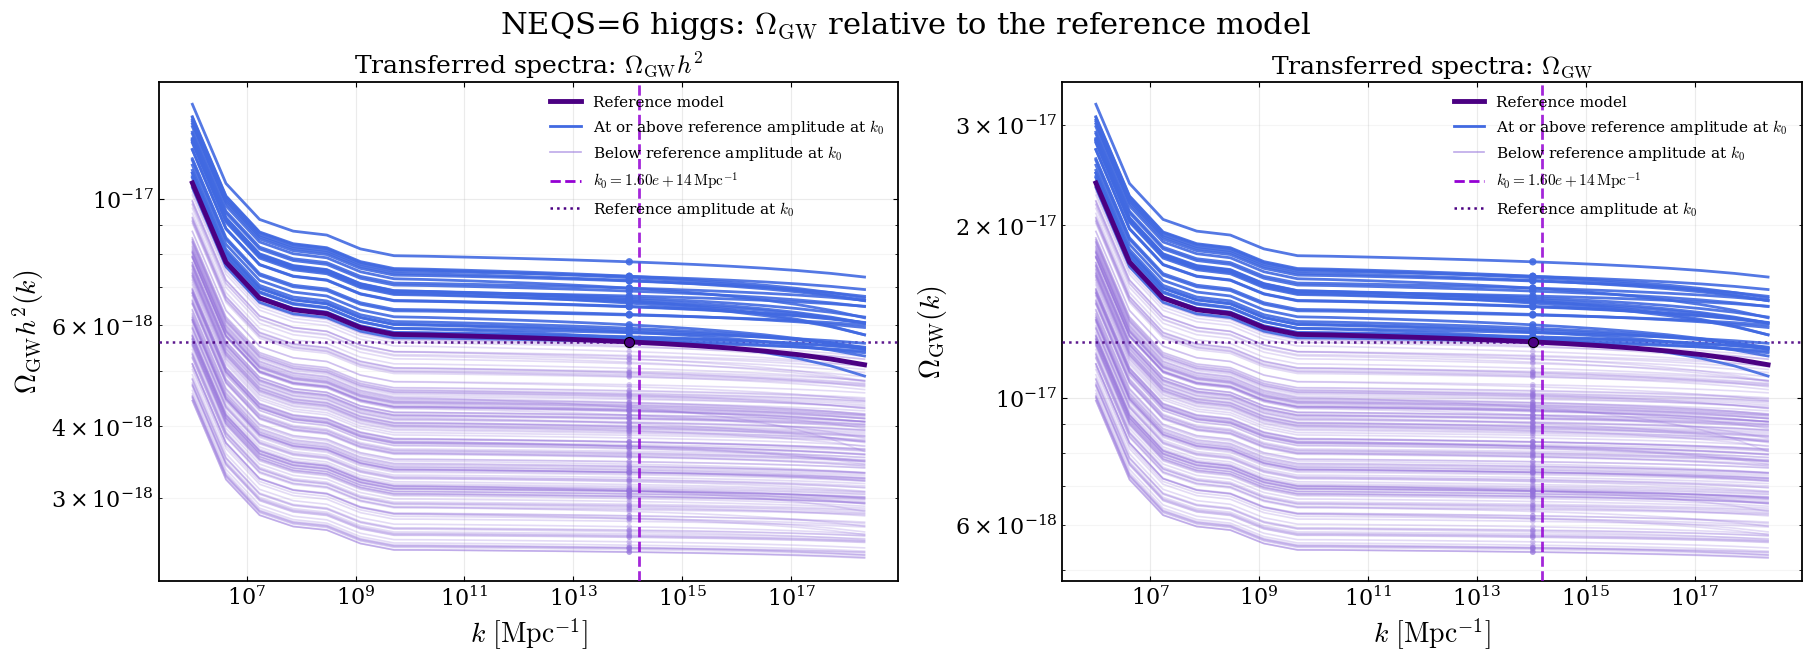


=== OmegaGW reference-threshold summary ===
Accepted models read       : 200
Usable spectra loaded      : 200
Reference models           : 1
Above/equal reference      : 29
Below reference            : 170
Do not cover k0            : 0
Insufficient TF overlap    : 0
Missing spectrum files     : 0
Rejected invalid spectra   : 0

Reference values:
  OmegaGW h^2(k0) = 5.617352e-18
  OmegaGW(k0)     = 1.251359e-17

Models at or above the reference amplitude:
     eps       sig          lam2          lam3  OmegaGW_h2_at_k0  OmegaGW_at_k0  OmegaGW_h2_ratio_to_reference  k_nearest_k0
0.000350 -0.035759 -3.002876e-04 -2.851989e-05      7.752084e-18   1.726907e-17                       1.380025  1.065015e+14
0.000350 -0.034736  2.117266e-04 -1.178391e-05      7.314630e-18   1.629457e-17                       1.302149  1.065015e+14
0.000335 -0.034992 -3.982581e-04 -3.457662e-05      7.310833e-18   1.628611e-17                       1.301473  1.065015e+14
0.000269 -0.035611  8.912165e-05 -8.394

In [49]:
omega6_threshold_df = plot_omegaGW_reference_threshold(
    NEQS=6,
    base_path_root=base_path_root,
    tf_k_invMpc=tf_k_invMpc,
    tf_median=tf_median,
    model_tag="higgs",
    h=0.67,
    k0=1.6e14,

    below_color="mediumpurple",
    pass_color="royalblue",
    reference_color="indigo",
    marker_color="darkviolet",

    below_alpha=0.25,
    pass_alpha=0.90,
    below_lw=1.2,
    pass_lw=2.0,
    reference_lw=3.5,

    save_name=(
        "neqs6_higgs_omegaGW_"
        "reference_threshold.pdf"
    ),
)

Now, for PTA hmm.



